# MovieLens-25M Recommender — v6: persistent content fusion, hyperparameter search, patience-based training

Builds on `recommend-v5.ipynb` (weighted EASE, EASE+ItemKNN ensemble,
adaptive hybrid, content-fused SASRec, LightGCN, LambdaRank stacker). Four
changes on top of v5, aimed squarely at your three asks — fine-tune more,
train longer, and tune hyperparameters:

## What's new and why

| Addition | What changed | Why it can help beyond v5 |
|---|---|---|
| **Persistent (residual) content fusion** instead of content-only-at-init | `item_embedding = learnable_id_embedding + sigmoid(gate) * fixed_content_vector`, every forward pass | v5 used content only to *initialize* the embedding table — over enough training epochs, gradient descent can drift arbitrarily far from that starting point and the content signal quietly disappears. Making it a standing residual term (with a learned gate controlling how much to trust it) means content keeps contributing regardless of how long you train, which directly matters once "train longer" is on the table. |
| **Lightweight hyperparameter search** for SASRec (dim / heads / blocks / dropout) and LightGCN (dim / layers / lr) | short probe trials (few epochs each) ranked by val NDCG, winner gets the full training run | v5 hardcoded these. A short random/grid search picks a materially better starting configuration before spending the full training budget on it — cheap relative to a full run, and the usual first thing you'd tune. |
| **Patience-based early stopping + cosine LR schedule + gradient clipping** | epoch caps raised (`SASREC_MAX_EPOCHS`, `LIGHTGCN_MAX_EPOCHS`), training now stops on `PATIENCE` epochs without val-NDCG improvement rather than a fixed count | "Train longer" without early stopping just risks overfitting past the point the fixed-epoch v5 runs happened to stop at. This lets both models run as long as they're still improving and no longer, with warmup + cosine decay so the extra epochs are actually used well instead of bouncing around a noisy loss surface. |
| **EASE: coarse-to-fine lambda search** | after the original grid, a second finer sweep zooms in around the best coarse value | The v5 grid (`100...1000`) is coarse; a quick second pass around whatever it picked is a cheap way to squeeze a bit more out of the one model that's basically free to refit. |

## Order and cost notes

Content fine-tuning (section 13) still runs before SASRec/LightGCN, since
both now depend on `content_emb_ft` for their residual fusion term as well
as their init. The two HPO searches add real wall-clock time (each probe
trial is a short training run) — set `SASREC_RUN_HPO` / `LIGHTGCN_RUN_HPO`
to `False` to skip straight to training with the current hardcoded config
if you're compute-constrained on a given run.

## Honest expectations, once more

None of this changes the model families from v5 — it's the same five
signals (EASE, ItemKNN, SASRec, LightGCN, content) feeding the same
LambdaRank stacker, just each individually better-tuned and more robust to
training length. If a specific piece still isn't earning its keep after
this pass, section 21's notes cover what that usually means.


## 1. Configuration

In [1]:
# ============================================================
# CONFIGURATION
# ============================================================

from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/garymk/movielens-25m-dataset/ml-25m")
OUT_DIR  = Path("/kaggle/working")

# --- Implicit feedback ---------------------------------------------------
POSITIVE_THRESHOLD = 4.0

# --- k-core filtering ----------------------------------------------------
MIN_ITEM_INTERACTIONS = 20
MIN_USER_INTERACTIONS = 10
KCORE_MAX_PASSES = 10

# --- Item budget -----------------------------------------------------------
MAX_ITEMS = 20_000

# --- Evaluation protocol -------------------------------------------------
TEST_N_PER_USER = 5
VAL_N_PER_USER  = 5
MIN_TRAIN_PER_USER = 5

EVAL_USERS   = 10_000
TUNING_USERS = 3_000
K_VALUES     = (5, 10, 20, 50)
PRIMARY_K    = 10

# --- Interaction weighting ---------------------------------------------------
WEIGHT_SCHEME = "both"
RECENCY_HALF_LIFE_DAYS = 365.0 * 2

# --- Models --------------------------------------------------------------------
EASE_LAMBDAS   = [100.0, 200.0, 300.0, 500.0, 750.0, 1000.0]
EASE_LAMBDA_REFINE = True     # NEW: after the coarse grid, zoom in around the best value
EASE_REFINE_FACTORS = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
ITEMKNN_K      = 200
ITEMKNN_SHRINK = 100.0
SVD_FACTORS    = 256

# --- Content model -------------------------------------------------------------
USE_CONTENT_SBERT = False
SBERT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
CONTENT_KNN_K = 200
MAX_TAGS_PER_ITEM = 40

# --- Hybrid blending -------------------------------------------------------------
HYBRID_ALPHAS = [1.0, 0.98, 0.95, 0.9, 0.8, 0.7, 0.5, 0.0]
ADAPTIVE_BUCKETS = ((5, 20), (20, 50), (50, 150), (150, 10**9))
ADAPTIVE_ALPHA_GRID = [1.0, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.3]
ENSEMBLE_BETAS = [1.0, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5]

# --- Content encoder fine-tuning ------------------------------------------------
# Needs internet access to download the base SBERT checkpoint the first time.
# Set False to fall back to the base TF-IDF/frozen-SBERT embeddings everywhere
# below (SASRec and LightGCN warm-starts included).
FINETUNE_CONTENT_ENCODER = False
FINETUNE_BASE_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
FINETUNE_EPOCHS = 2
FINETUNE_BATCH_SIZE = 128
FINETUNE_MAX_PAIRS_PER_USER = 20

# --- SASRec (transformer CF) ----------------------------------------------------
TRAIN_SASREC = True
SASREC_CONTENT_FUSION = True   # NEW: content contributes as a persistent residual, not just init
SASREC_MAX_LEN = 50
SASREC_EMBED_DIM = 64          # default / fallback if SASREC_RUN_HPO is False
SASREC_N_BLOCKS = 2
SASREC_N_HEADS = 2
SASREC_DROPOUT = 0.2
SASREC_BATCH_SIZE = 256
SASREC_LR = 1e-3
SASREC_WEIGHT_DECAY = 0.0

# NEW: patience-based early stopping instead of a fixed epoch count
SASREC_MAX_EPOCHS = 40
SASREC_PATIENCE = 5
SASREC_GRAD_CLIP = 1.0
SASREC_WARMUP_STEPS = 500

# NEW: lightweight hyperparameter search — short probe trials, winner trains fully
SASREC_RUN_HPO = True
SASREC_HPO_EPOCHS = 4
SASREC_HPO_TRIALS = [
    {"dim": 64,  "n_heads": 2, "n_blocks": 2, "dropout": 0.2},
    {"dim": 64,  "n_heads": 4, "n_blocks": 2, "dropout": 0.3},
    {"dim": 128, "n_heads": 2, "n_blocks": 2, "dropout": 0.3},
    {"dim": 128, "n_heads": 4, "n_blocks": 3, "dropout": 0.4},
]

# --- LightGCN (graph CF) -----------------------------------------------------------
TRAIN_LIGHTGCN = True
LIGHTGCN_CONTENT_FUSION = True   # NEW: content contributes as a persistent residual, not just init
LIGHTGCN_DIM = 64                # default / fallback if LIGHTGCN_RUN_HPO is False
LIGHTGCN_LAYERS = 3
LIGHTGCN_BATCH_SIZE = 65536
LIGHTGCN_LR = 1e-3
LIGHTGCN_L2 = 1e-4

# NEW: patience-based early stopping
LIGHTGCN_MAX_EPOCHS = 40
LIGHTGCN_PATIENCE = 4
LIGHTGCN_GRAD_CLIP = 5.0

# NEW: lightweight hyperparameter search
LIGHTGCN_RUN_HPO = True
LIGHTGCN_HPO_EPOCHS = 4
LIGHTGCN_HPO_TRIALS = [
    {"dim": 64,  "layers": 2, "lr": 1e-3},
    {"dim": 64,  "layers": 3, "lr": 1e-3},
    {"dim": 128, "layers": 2, "lr": 1e-3},
    {"dim": 128, "layers": 3, "lr": 1e-3},
]

# --- Stacking reranker -----------------------------------------------------------
TRAIN_STACKER = True
STACK_CANDIDATES_PER_MODEL = 100
STACK_RANDOM_NEGATIVES = 50

SEED = 42
BATCH_SIZE = 512

OUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import gc
import time
import warnings
from contextlib import contextmanager

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.linalg import svds

warnings.filterwarnings("ignore")
rng = np.random.default_rng(SEED)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)


@contextmanager
def timed(label):
    print(f"  {label} ...", flush=True)
    t0 = time.time()
    yield
    print(f"  {label}: {time.time() - t0:.1f}s", flush=True)


def mem_mb(*arrays):
    return sum(a.nbytes for a in arrays) / 1e6


print("numpy", np.__version__, "| pandas", pd.__version__)


numpy 2.0.2 | pandas 2.3.3


### GPU check

Decides whether `DataParallel` is used for SASRec/LightGCN training.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

N_GPUS = torch.cuda.device_count()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_DATAPARALLEL = N_GPUS > 1

print("torch", torch.__version__)
print(f"  CUDA available: {torch.cuda.is_available()}  |  GPUs: {N_GPUS}")
for i in range(N_GPUS):
    print(f"    [{i}] {torch.cuda.get_device_name(i)}")
if N_GPUS == 0:
    print("  no GPU found — SASRec/LightGCN training and content fine-tuning will run on "
          "CPU (slow; consider setting TRAIN_SASREC / TRAIN_LIGHTGCN / "
          "FINETUNE_CONTENT_ENCODER to False)")


torch 2.10.0+cu128
  CUDA available: True  |  GPUs: 2
    [0] Tesla T4
    [1] Tesla T4


## 2. Load

In [4]:
def load_data(data_dir: Path):
    with timed("ratings.csv"):
        ratings = pd.read_csv(
            data_dir / "ratings.csv",
            dtype={
                "userId": np.int32,
                "movieId": np.int32,
                "rating": np.float32,
                "timestamp": np.int64,
            },
        )

    with timed("movies.csv"):
        movies = pd.read_csv(data_dir / "movies.csv", dtype={"movieId": np.int32})

    with timed("tags.csv"):
        tags = pd.read_csv(
            data_dir / "tags.csv",
            dtype={"userId": np.int32, "movieId": np.int32, "timestamp": np.int64},
        )

    n_users = ratings["userId"].nunique()
    n_items = ratings["movieId"].nunique()
    density = len(ratings) / (n_users * n_items)

    print()
    print(f"  ratings  {len(ratings):>12,}")
    print(f"  users    {n_users:>12,}")
    print(f"  movies   {n_items:>12,}")
    print(f"  tags     {len(tags):>12,}")
    print(f"  density  {density:>12.6%}")
    print(f"  span     {pd.to_datetime(ratings['timestamp'].min(), unit='s').date()} "
          f"to {pd.to_datetime(ratings['timestamp'].max(), unit='s').date()}")

    return ratings, movies, tags


ratings_raw, movies_raw, tags_raw = load_data(DATA_DIR)


  ratings.csv ...
  ratings.csv: 18.1s
  movies.csv ...
  movies.csv: 0.1s
  tags.csv ...
  tags.csv: 1.1s

  ratings    25,000,095
  users         162,541
  movies         59,047
  tags        1,093,360
  density     0.260484%
  span     1995-01-09 to 2019-11-21


## 3. Implicit feedback and k-core filtering

In [5]:
def build_interactions(ratings: pd.DataFrame) -> pd.DataFrame:
    df = ratings.loc[
        ratings["rating"] >= POSITIVE_THRESHOLD, ["userId", "movieId", "rating", "timestamp"]
    ].copy()
    df = df.sort_values("timestamp").drop_duplicates(subset=["userId", "movieId"], keep="last")
    print(f"  {len(ratings):,} ratings -> {len(df):,} positives "
          f"(rating >= {POSITIVE_THRESHOLD})")
    return df


def kcore_filter(df: pd.DataFrame) -> pd.DataFrame:
    for it in range(1, KCORE_MAX_PASSES + 1):
        before = len(df)

        item_counts = df["movieId"].value_counts()
        keep_items = item_counts.index[item_counts >= MIN_ITEM_INTERACTIONS]
        df = df[df["movieId"].isin(keep_items)]

        user_counts = df["userId"].value_counts()
        keep_users = user_counts.index[user_counts >= MIN_USER_INTERACTIONS]
        df = df[df["userId"].isin(keep_users)]

        print(f"    pass {it}: {before:,} -> {len(df):,} "
              f"({df['userId'].nunique():,} users, {df['movieId'].nunique():,} items)")
        if len(df) == before:
            break
    return df.copy()


def cap_items(df: pd.DataFrame, max_items: int) -> pd.DataFrame:
    n = df["movieId"].nunique()
    if n <= max_items:
        print(f"  {n:,} items, under the {max_items:,} cap")
        return df
    keep = df["movieId"].value_counts().index[:max_items]
    out = df[df["movieId"].isin(keep)].copy()
    print(f"  capped {n:,} -> {max_items:,} items "
          f"({len(out) / len(df):.1%} of interactions retained)")
    uc = out["userId"].value_counts()
    out = out[out["userId"].isin(uc.index[uc >= MIN_USER_INTERACTIONS])].copy()
    return out


inter = build_interactions(ratings_raw)
inter = kcore_filter(inter)
inter = cap_items(inter, MAX_ITEMS)

print()
print(f"  final: {len(inter):,} interactions | "
      f"{inter['userId'].nunique():,} users | {inter['movieId'].nunique():,} items")
print(f"  density: {len(inter) / (inter['userId'].nunique() * inter['movieId'].nunique()):.4%}")

del ratings_raw
gc.collect()


  25,000,095 ratings -> 12,452,811 positives (rating >= 4.0)
    pass 1: 12,452,811 -> 12,287,125 (154,021 users, 12,142 items)
    pass 2: 12,287,125 -> 12,286,805 (154,019 users, 12,126 items)
    pass 3: 12,286,805 -> 12,286,805 (154,019 users, 12,126 items)
  12,126 items, under the 20,000 cap

  final: 12,286,805 interactions | 154,019 users | 12,126 items
  density: 0.6579%


40

### Contiguous index mapping

In [6]:
unique_users = np.sort(inter["userId"].unique())
unique_items = np.sort(inter["movieId"].unique())

user_to_idx = {u: i for i, u in enumerate(unique_users)}
item_to_idx = {m: i for i, m in enumerate(unique_items)}
idx_to_user = unique_users
idx_to_item = unique_items

N_USERS = len(unique_users)
N_ITEMS = len(unique_items)

inter["user_idx"] = inter["userId"].map(user_to_idx).astype(np.int32)
inter["item_idx"] = inter["movieId"].map(item_to_idx).astype(np.int32)

_m = movies_raw.drop_duplicates("movieId").set_index("movieId")
item_meta = _m.reindex(unique_items).reset_index()
item_meta["item_idx"] = np.arange(N_ITEMS)
item_meta["title"] = item_meta["title"].fillna("(unknown)")
item_meta["genres"] = item_meta["genres"].fillna("(no genres listed)")

assert (item_meta["movieId"].values == unique_items).all(), "metadata misaligned"
assert item_meta["item_idx"].is_monotonic_increasing

print(f"  {N_USERS:,} users x {N_ITEMS:,} items")
print(f"  EASE Gram matrix will be ~{8 * N_ITEMS**2 / 1e9:.2f} GB (float64)")
item_meta.head()


  154,019 users x 12,126 items
  EASE Gram matrix will be ~1.18 GB (float64)


,movieId,title,genres,item_idx
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1
2,3,Grumpier Old Men (1995),Comedy|Romance,2
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,3
4,5,Father of the Bride Part II (1995),Comedy,4


## 4. Split

Leave-last-N-out, chronological, per user.

In [7]:
def leave_last_n_split(df: pd.DataFrame, test_n: int, val_n: int, min_train: int):
    df = df.sort_values(["user_idx", "timestamp"], kind="mergesort")

    rank_from_end = df.groupby("user_idx").cumcount(ascending=False)
    n_per_user = df.groupby("user_idx")["item_idx"].transform("size")

    eligible = n_per_user >= (test_n + val_n + min_train)

    is_test = eligible & (rank_from_end < test_n)
    is_val = eligible & (rank_from_end >= test_n) & (rank_from_end < test_n + val_n)

    train = df[~(is_test | is_val)]
    val = df[is_val]
    test = df[is_test]

    print(f"  train {len(train):>10,}  ({train['user_idx'].nunique():,} users)")
    print(f"  val   {len(val):>10,}  ({val['user_idx'].nunique():,} users)")
    print(f"  test  {len(test):>10,}  ({test['user_idx'].nunique():,} users)")
    print(f"  users too short to split: {N_USERS - test['user_idx'].nunique():,}")
    return train, val, test


train_df, val_df, test_df = leave_last_n_split(
    inter, TEST_N_PER_USER, VAL_N_PER_USER, MIN_TRAIN_PER_USER
)

_tr_max = train_df.groupby("user_idx")["timestamp"].max()
_te_min = test_df.groupby("user_idx")["timestamp"].min()
_shared = _tr_max.index.intersection(_te_min.index)
assert (_tr_max.loc[_shared] <= _te_min.loc[_shared]).all(), "temporal leakage"
print("  temporal ordering verified")


  train 10,882,095  (154,019 users)
  val      702,355  (140,471 users)
  test     702,355  (140,471 users)
  users too short to split: 13,548
  temporal ordering verified


## 5. Interaction matrices — binary and weighted

`X_train` stays plain binary (used for masking/eval/PureSVD/ItemKNN/
LightGCN's graph edges), `X_train_w` is confidence+recency-weighted and
feeds only EASE. `train_seqs` (section 14) is a third view — ordered
sequences for SASRec — all built strictly from `train_df`.

In [8]:
def to_csr(df: pd.DataFrame, n_users: int, n_items: int, values=None) -> sp.csr_matrix:
    if values is None:
        values = np.ones(len(df), dtype=np.float32)
    return sp.csr_matrix(
        (values, (df["user_idx"].values, df["item_idx"].values)),
        shape=(n_users, n_items),
        dtype=np.float32,
    )


def interaction_weights(df: pd.DataFrame, scheme: str) -> np.ndarray:
    if scheme == "binary":
        return np.ones(len(df), dtype=np.float32)

    w = np.ones(len(df), dtype=np.float32)

    if scheme in ("rating", "both"):
        w = w * (1.0 + (df["rating"].values - POSITIVE_THRESHOLD)).astype(np.float32)

    if scheme in ("recency", "both"):
        max_ts = df["timestamp"].max()
        age_days = (max_ts - df["timestamp"].values) / 86400.0
        decay = np.exp(-np.log(2.0) * age_days / RECENCY_HALF_LIFE_DAYS).astype(np.float32)
        w = w * decay

    return w


X_train = to_csr(train_df, N_USERS, N_ITEMS)
X_val   = to_csr(val_df, N_USERS, N_ITEMS)
X_test  = to_csr(test_df, N_USERS, N_ITEMS)

train_weights = interaction_weights(train_df, WEIGHT_SCHEME)
X_train_w = to_csr(train_df, N_USERS, N_ITEMS, values=train_weights)

X_train.sort_indices()
X_val.sort_indices()
X_test.sort_indices()
X_train_w.sort_indices()

train_counts = np.diff(X_train.indptr)
val_users_all = np.where((np.diff(X_val.indptr) > 0) & (train_counts >= MIN_TRAIN_PER_USER))[0]
test_users_all = np.where((np.diff(X_test.indptr) > 0) & (train_counts >= MIN_TRAIN_PER_USER))[0]

eval_users = rng.permutation(test_users_all)[:EVAL_USERS]
tune_users = rng.permutation(val_users_all)[:TUNING_USERS]

item_pop = np.asarray(X_train.sum(axis=0)).ravel()
item_pop_prob = np.maximum(item_pop, 1.0) / item_pop.sum()

print(f"  X_train   {X_train.shape}, nnz {X_train.nnz:,}")
print(f"  X_train_w weight scheme = {WEIGHT_SCHEME!r}")
print(f"  evaluating on {len(eval_users):,} test users, tuning on {len(tune_users):,} val users")


  X_train   (154019, 12126), nnz 10,882,095
  X_train_w weight scheme = 'both'
  evaluating on 10,000 test users, tuning on 3,000 val users


## 6. Evaluation harness

In [9]:
def _dcg_discounts(k: int) -> np.ndarray:
    return 1.0 / np.log2(np.arange(2, k + 2))


_IDCG_CACHE = {}


def _idcg_table(k: int) -> np.ndarray:
    if k not in _IDCG_CACHE:
        _IDCG_CACHE[k] = np.cumsum(_dcg_discounts(k))
    return _IDCG_CACHE[k]


def evaluate(model, users, X_seen, X_truth, ks=K_VALUES, batch_size=BATCH_SIZE,
             collect_items=True):
    ks = tuple(sorted(ks))
    max_k = max(ks)
    acc = {k: {"recall": [], "precision": [], "ndcg": [], "hit": []} for k in ks}
    recommended = np.zeros(N_ITEMS, dtype=bool) if collect_items else None
    novelty_sum, novelty_n = 0.0, 0

    for start in range(0, len(users), batch_size):
        batch = users[start:start + batch_size]
        scores = np.asarray(model.score(batch), dtype=np.float32)

        seen = X_seen[batch]
        rows = np.repeat(np.arange(len(batch)), np.diff(seen.indptr))
        scores[rows, seen.indices] = -np.inf

        part = np.argpartition(-scores, max_k - 1, axis=1)[:, :max_k]
        r = np.arange(len(batch))[:, None]
        order = np.argsort(-scores[r, part], axis=1)
        topk = part[r, order]

        truth = X_truth[batch]
        truth_dense = np.zeros((len(batch), N_ITEMS), dtype=bool)
        trows = np.repeat(np.arange(len(batch)), np.diff(truth.indptr))
        truth_dense[trows, truth.indices] = True

        hits = truth_dense[r, topk]
        n_rel = truth_dense.sum(axis=1)

        if collect_items:
            recommended[np.unique(topk[:, :PRIMARY_K])] = True
            novelty_sum += -np.log2(item_pop_prob[topk[:, :PRIMARY_K]]).sum()
            novelty_n += topk[:, :PRIMARY_K].size

        for k in ks:
            hk = hits[:, :k]
            n_hit = hk.sum(axis=1)
            acc[k]["recall"].append(n_hit / np.maximum(n_rel, 1))
            acc[k]["precision"].append(n_hit / k)
            acc[k]["hit"].append((n_hit > 0).astype(np.float32))

            dcg = (hk * _dcg_discounts(k)).sum(axis=1)
            idcg = _idcg_table(k)[np.minimum(n_rel, k) - 1]
            acc[k]["ndcg"].append(dcg / np.maximum(idcg, 1e-12))

        del scores, truth_dense

    out = {}
    for k in ks:
        for name, chunks in acc[k].items():
            out[f"{name}@{k}"] = float(np.concatenate(chunks).mean())
    if collect_items:
        out["coverage"] = float(recommended.mean())
        out["novelty"] = float(novelty_sum / max(novelty_n, 1))
    out["_per_user_ndcg"] = np.concatenate(acc[PRIMARY_K]["ndcg"])
    return out


def bootstrap_ci(values, n_boot=1000, alpha=0.05):
    values = np.asarray(values)
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))
    means = values[idx].mean(axis=1)
    return float(np.percentile(means, 100 * alpha / 2)), float(np.percentile(means, 100 * (1 - alpha / 2)))


def report(name, metrics):
    lo, hi = bootstrap_ci(metrics["_per_user_ndcg"])
    parts = []
    for k in (PRIMARY_K, 20):
        if f"recall@{k}" in metrics:
            parts.append(f"Recall@{k}={metrics[f'recall@{k}']:.4f}")
            parts.append(f"NDCG@{k}={metrics[f'ndcg@{k}']:.4f}")
    parts.append(f"HR@{PRIMARY_K}={metrics[f'hit@{PRIMARY_K}']:.4f}")
    parts.append(f"P@{PRIMARY_K}={metrics[f'precision@{PRIMARY_K}']:.4f}")
    print(f"\n{name}")
    print("  " + "  ".join(parts))
    tail = f"  NDCG@{PRIMARY_K} 95% CI [{lo:.4f}, {hi:.4f}]"
    if "coverage" in metrics:
        tail += f"  |  coverage={metrics['coverage']:.3f}  novelty={metrics['novelty']:.2f}"
    print(tail)


RESULTS = {}
print("harness ready")


harness ready


## 7. Baselines (Popularity, ItemKNN, PureSVD — on binary `X_train`)

In [10]:
class PopularityModel:
    name = "Popularity"

    def fit(self, X):
        self.scores_ = np.asarray(X.sum(axis=0)).ravel().astype(np.float32)
        return self

    def score(self, users):
        return np.tile(self.scores_, (len(users), 1))


with timed("Popularity"):
    pop_model = PopularityModel().fit(X_train)

RESULTS["Popularity"] = evaluate(pop_model, eval_users, X_train, X_test)
report("Popularity", RESULTS["Popularity"])


  Popularity ...
  Popularity: 0.0s

Popularity
  Recall@10=0.0436  NDCG@10=0.0364  Recall@20=0.0753  NDCG@20=0.0498  HR@10=0.1727  P@10=0.0218
  NDCG@10 95% CI [0.0344, 0.0382]  |  coverage=0.008  novelty=7.99


In [11]:
class ItemKNN:
    name = "ItemKNN"

    def __init__(self, k=ITEMKNN_K, shrink=ITEMKNN_SHRINK, chunk=512):
        self.k, self.shrink, self.chunk = k, shrink, chunk

    def fit(self, X):
        Xc = X.tocsc().astype(np.float32)
        norms = np.sqrt(np.asarray(Xc.multiply(Xc).sum(axis=0)).ravel())
        n_items = X.shape[1]

        rows, cols, vals = [], [], []
        for start in range(0, n_items, self.chunk):
            end = min(start + self.chunk, n_items)
            block = (Xc[:, start:end].T @ Xc).toarray().astype(np.float32, copy=False)

            denom = norms[start:end, None] * norms[None, :] + self.shrink + 1e-8
            block /= denom
            block[np.arange(end - start), np.arange(start, end)] = 0.0

            kk = min(self.k, n_items - 1)
            idx = np.argpartition(-block, kk - 1, axis=1)[:, :kk]
            r = np.arange(end - start)[:, None]
            v = block[r, idx]
            keep = v > 0

            rows.append((np.repeat(np.arange(start, end), kk))[keep.ravel()])
            cols.append(idx.ravel()[keep.ravel()])
            vals.append(v.ravel()[keep.ravel()])
            del block

        self.S_ = sp.csr_matrix(
            (np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))),
            shape=(n_items, n_items), dtype=np.float32,
        )
        print(f"    similarity nnz {self.S_.nnz:,} "
              f"({self.S_.nnz / n_items:.0f} neighbours/item)")
        return self

    def score(self, users):
        return (X_train[users] @ self.S_).toarray().astype(np.float32, copy=False)


with timed("ItemKNN fit"):
    knn_model = ItemKNN().fit(X_train)

RESULTS["ItemKNN"] = evaluate(knn_model, eval_users, X_train, X_test)
report("ItemKNN", RESULTS["ItemKNN"])


  ItemKNN fit ...
    similarity nnz 2,425,200 (200 neighbours/item)
  ItemKNN fit: 19.7s

ItemKNN
  Recall@10=0.0591  NDCG@10=0.0489  Recall@20=0.1033  NDCG@20=0.0678  HR@10=0.2257  P@10=0.0295
  NDCG@10 95% CI [0.0467, 0.0511]  |  coverage=0.056  novelty=8.75


In [12]:
class PureSVD:
    name = "PureSVD"

    def __init__(self, factors=SVD_FACTORS):
        self.factors = factors

    def fit(self, X):
        _, _, vt = svds(X.astype(np.float32), k=self.factors)
        self.V_ = np.ascontiguousarray(vt.T, dtype=np.float32)
        return self

    def score(self, users):
        U = X_train[users].toarray().astype(np.float32, copy=False)
        return (U @ self.V_) @ self.V_.T


with timed(f"PureSVD ({SVD_FACTORS} factors)"):
    svd_model = PureSVD().fit(X_train)

RESULTS["PureSVD"] = evaluate(svd_model, eval_users, X_train, X_test)
report("PureSVD", RESULTS["PureSVD"])


  PureSVD (256 factors) ...
  PureSVD (256 factors): 37.5s

PureSVD
  Recall@10=0.0494  NDCG@10=0.0406  Recall@20=0.0834  NDCG@20=0.0551  HR@10=0.2061  P@10=0.0247
  NDCG@10 95% CI [0.0387, 0.0427]  |  coverage=0.106  novelty=10.66


## 8. EASE — fit on the weighted matrix

In [13]:
class EASE:
    name = "EASE"

    def __init__(self, lam=250.0):
        self.lam = lam

    def fit(self, X):
        n_items = X.shape[1]

        G = (X.T @ X).toarray().astype(np.float64)
        diag = np.diag_indices(n_items)
        G[diag] += self.lam

        P = np.linalg.inv(G)
        del G
        gc.collect()

        B = P / (-np.diag(P))
        B[diag] = 0.0

        self.B_ = np.ascontiguousarray(B, dtype=np.float32)
        del P, B
        gc.collect()

        print(f"    B: {self.B_.shape}, {mem_mb(self.B_):.0f} MB float32")
        return self

    def score(self, users):
        return np.asarray((X_train[users] @ self.B_), dtype=np.float32)


sweep = []
best_lam, best_ndcg, best_model = None, -1.0, None

for lam in EASE_LAMBDAS:
    with timed(f"EASE lambda={lam:g}"):
        m = EASE(lam=lam).fit(X_train_w)
    v = evaluate(m, tune_users, X_train, X_val, ks=(PRIMARY_K,), collect_items=False)
    score = v[f"ndcg@{PRIMARY_K}"]
    sweep.append({"lambda": lam, f"val_ndcg@{PRIMARY_K}": score})
    print(f"    val NDCG@{PRIMARY_K} = {score:.4f}")
    if score > best_ndcg:
        best_ndcg, best_lam, best_model = score, lam, m
    else:
        del m
        gc.collect()

sweep_df = pd.DataFrame(sweep)
print(f"\n  coarse best lambda = {best_lam:g} (val NDCG@{PRIMARY_K} = {best_ndcg:.4f})")
sweep_df


  EASE lambda=100 ...
    B: (12126, 12126), 588 MB float32
  EASE lambda=100: 67.4s
    val NDCG@10 = 0.0769
  EASE lambda=200 ...
    B: (12126, 12126), 588 MB float32
  EASE lambda=200: 67.2s
    val NDCG@10 = 0.0778
  EASE lambda=300 ...
    B: (12126, 12126), 588 MB float32
  EASE lambda=300: 66.9s
    val NDCG@10 = 0.0777
  EASE lambda=500 ...
    B: (12126, 12126), 588 MB float32
  EASE lambda=500: 66.7s
    val NDCG@10 = 0.0776
  EASE lambda=750 ...
    B: (12126, 12126), 588 MB float32
  EASE lambda=750: 67.1s
    val NDCG@10 = 0.0768
  EASE lambda=1000 ...
    B: (12126, 12126), 588 MB float32
  EASE lambda=1000: 65.3s
    val NDCG@10 = 0.0761

  coarse best lambda = 200 (val NDCG@10 = 0.0778)


,lambda,val_ndcg@10
0,100.0,0.076933
1,200.0,0.077804
2,300.0,0.077727
3,500.0,0.077556
4,750.0,0.076808
5,1000.0,0.076117


### EASE — fine sweep around the coarse best (NEW)

Cheap: an EASE fit is a single matrix inversion, so zooming in around the
coarse winner costs a handful of extra inversions, not a retraining loop.

In [14]:
if EASE_LAMBDA_REFINE:
    refine_grid = sorted(set(round(best_lam * f, 1) for f in EASE_REFINE_FACTORS))
    refine_sweep = []
    for lam in refine_grid:
        with timed(f"EASE refine lambda={lam:g}"):
            m = EASE(lam=lam).fit(X_train_w)
        v = evaluate(m, tune_users, X_train, X_val, ks=(PRIMARY_K,), collect_items=False)
        score = v[f"ndcg@{PRIMARY_K}"]
        refine_sweep.append({"lambda": lam, f"val_ndcg@{PRIMARY_K}": score})
        print(f"    val NDCG@{PRIMARY_K} = {score:.4f}")
        if score > best_ndcg:
            best_ndcg, best_lam, best_model = score, lam, m
        else:
            del m
            gc.collect()

    refine_df = pd.DataFrame(refine_sweep)
    print(f"\n  final best lambda = {best_lam:g} (val NDCG@{PRIMARY_K} = {best_ndcg:.4f})")
else:
    refine_df = pd.DataFrame()
    print("EASE_LAMBDA_REFINE is False — keeping the coarse-sweep best.")

refine_df


  EASE refine lambda=100 ...
    B: (12126, 12126), 588 MB float32
  EASE refine lambda=100: 64.0s
    val NDCG@10 = 0.0769
  EASE refine lambda=150 ...
    B: (12126, 12126), 588 MB float32
  EASE refine lambda=150: 64.9s
    val NDCG@10 = 0.0773
  EASE refine lambda=200 ...
    B: (12126, 12126), 588 MB float32
  EASE refine lambda=200: 66.7s
    val NDCG@10 = 0.0778
  EASE refine lambda=250 ...
    B: (12126, 12126), 588 MB float32
  EASE refine lambda=250: 67.1s
    val NDCG@10 = 0.0776
  EASE refine lambda=300 ...
    B: (12126, 12126), 588 MB float32
  EASE refine lambda=300: 67.4s
    val NDCG@10 = 0.0777
  EASE refine lambda=400 ...
    B: (12126, 12126), 588 MB float32
  EASE refine lambda=400: 67.4s
    val NDCG@10 = 0.0776

  final best lambda = 200 (val NDCG@10 = 0.0778)


,lambda,val_ndcg@10
0,100.0,0.076933
1,150.0,0.077304
2,200.0,0.077804
3,250.0,0.077613
4,300.0,0.077727
5,400.0,0.077636


In [15]:
ease_model = best_model
RESULTS["EASE"] = evaluate(ease_model, eval_users, X_train, X_test)
report(f"EASE (lambda={best_lam:g}, weighting={WEIGHT_SCHEME!r})", RESULTS["EASE"])



EASE (lambda=200, weighting='both')
  Recall@10=0.0686  NDCG@10=0.0574  Recall@20=0.1155  NDCG@20=0.0773  HR@10=0.2722  P@10=0.0343
  NDCG@10 95% CI [0.0552, 0.0596]  |  coverage=0.125  novelty=9.37


## 9. EASE + ItemKNN ensemble

In [16]:
S_dense = knn_model.S_.toarray().astype(np.float32)


class EnsembleModel:
    name = "Ensemble"

    def __init__(self, B_ease, S_knn, beta=0.9):
        self.B_ease, self.S_knn, self.beta = B_ease, S_knn, beta

    def score(self, users):
        Xb = X_train[users]
        a = (Xb @ self.B_ease)
        b = (Xb @ self.S_knn)
        return np.asarray(self.beta * a + (1 - self.beta) * b, dtype=np.float32)


ens_rows = []
best_beta, best_beta_val = None, -1.0
for beta in ENSEMBLE_BETAS:
    e = EnsembleModel(ease_model.B_, S_dense, beta=beta)
    v = evaluate(e, tune_users, X_train, X_val, ks=(PRIMARY_K,), collect_items=False)
    s = v[f"ndcg@{PRIMARY_K}"]
    ens_rows.append({"beta (EASE weight)": beta, f"val_ndcg@{PRIMARY_K}": s})
    print(f"  beta={beta:<5} val NDCG@{PRIMARY_K}={s:.4f}")
    if s > best_beta_val:
        best_beta_val, best_beta = s, beta

ens_df = pd.DataFrame(ens_rows)
print(f"\n  best beta = {best_beta}")
ens_df


  beta=1.0   val NDCG@10=0.0778
  beta=0.95  val NDCG@10=0.0808
  beta=0.9   val NDCG@10=0.0815
  beta=0.8   val NDCG@10=0.0811
  beta=0.7   val NDCG@10=0.0784
  beta=0.6   val NDCG@10=0.0762
  beta=0.5   val NDCG@10=0.0756

  best beta = 0.9


,beta (EASE weight),val_ndcg@10
0,1.00,0.077804
1,0.95,0.080805
2,0.90,0.081465
3,0.80,0.081055
4,0.70,0.078376
5,0.60,0.076154
6,0.50,0.075575


In [17]:
ensemble_model = EnsembleModel(ease_model.B_, S_dense, beta=best_beta)
RESULTS["Ensemble"] = evaluate(ensemble_model, eval_users, X_train, X_test)
report(f"EASE+ItemKNN Ensemble (beta={best_beta})", RESULTS["Ensemble"])



EASE+ItemKNN Ensemble (beta=0.9)
  Recall@10=0.0685  NDCG@10=0.0570  Recall@20=0.1150  NDCG@20=0.0768  HR@10=0.2605  P@10=0.0343
  NDCG@10 95% CI [0.0546, 0.0594]  |  coverage=0.088  novelty=8.88


## 10. Content model — base embeddings (TF-IDF or frozen SBERT)

In [18]:
def build_item_text(tags: pd.DataFrame, meta: pd.DataFrame) -> pd.Series:
    t = tags.dropna(subset=["movieId", "tag"]).copy()
    t["tag"] = t["tag"].astype(str).str.strip().str.lower()
    t = t[(t["tag"] != "") & t["movieId"].isin(item_to_idx)]

    counts = t.groupby(["movieId", "tag"]).size().rename("n").reset_index()
    counts = counts.sort_values(["movieId", "n"], ascending=[True, False])
    counts = counts.groupby("movieId").head(MAX_TAGS_PER_ITEM)
    tag_text = counts.groupby("movieId")["tag"].apply(" ".join)

    year = meta["title"].str.extract(r"\((\d{4})\)")[0].fillna("")
    decade = year.where(year == "", (year.str[:3] + "0s"))

    genres = meta["genres"].str.replace("|", " ", regex=False).str.lower()
    genres = genres.replace("(no genres listed)", "")

    tags_aligned = meta["movieId"].map(tag_text).fillna("")

    text = (genres + " " + decade + " " + tags_aligned).str.strip()
    print(f"  {(text == '').sum():,} items with empty text "
          f"({(text == '').mean():.1%})")
    print(f"  median text length: {text.str.split().str.len().median():.0f} tokens")
    return text


item_text = build_item_text(tags_raw, item_meta)
item_meta["text"] = item_text
item_meta[["movieId", "title", "genres", "text"]].head(5)


  0 items with empty text (0.0%)
  median text length: 32 tokens


,movieId,title,genres,text
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,adventure animation children comedy fantasy 19...
1,2,Jumanji (1995),Adventure|Children|Fantasy,adventure children fantasy 1990s robin william...
2,3,Grumpier Old Men (1995),Comedy|Romance,comedy romance 1990s fishing jack lemmon moldy...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,comedy drama romance 1990s chick flick charact...
4,5,Father of the Bride Part II (1995),Comedy,comedy 1990s steve martin family pregnancy wed...


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

def build_content_embeddings(text: pd.Series) -> np.ndarray:
    if USE_CONTENT_SBERT:
        from sentence_transformers import SentenceTransformer
        enc = SentenceTransformer(SBERT_MODEL, device=DEVICE.type)
        emb = enc.encode(
            text.tolist(), batch_size=256, convert_to_numpy=True,
            normalize_embeddings=True, show_progress_bar=True,
        )
        return emb.astype(np.float32)

    global _tfidf_vec
    _tfidf_vec = TfidfVectorizer(
        min_df=3, max_features=60_000, sublinear_tf=True, ngram_range=(1, 2)
    )
    M = _tfidf_vec.fit_transform(text.tolist())
    M = normalize(M, norm="l2", axis=1)
    print(f"  TF-IDF vocabulary: {len(_tfidf_vec.vocabulary_):,}")
    return M.astype(np.float32)


with timed("content embeddings (base)"):
    content_emb = build_content_embeddings(item_text)

print(f"  shape {content_emb.shape}")
assert content_emb.shape[0] == N_ITEMS, "content rows must align with item_idx"


  content embeddings (base) ...
  TF-IDF vocabulary: 29,298
  content embeddings (base): 1.7s
  shape (12126, 29298)


In [20]:
def content_knn(emb, k=CONTENT_KNN_K, chunk=512) -> sp.csr_matrix:
    n = emb.shape[0]
    rows, cols, vals = [], [], []
    for start in range(0, n, chunk):
        end = min(start + chunk, n)
        block = emb[start:end] @ emb.T
        block = (block.toarray() if sp.issparse(block) else np.asarray(block))
        block = block.astype(np.float32, copy=False)
        block[np.arange(end - start), np.arange(start, end)] = 0.0

        kk = min(k, n - 1)
        idx = np.argpartition(-block, kk - 1, axis=1)[:, :kk]
        r = np.arange(end - start)[:, None]
        v = block[r, idx]
        keep = (v > 1e-6).ravel()

        rows.append(np.repeat(np.arange(start, end), kk)[keep])
        cols.append(idx.ravel()[keep])
        vals.append(v.ravel()[keep])
        del block

    S = sp.csr_matrix(
        (np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))),
        shape=(n, n), dtype=np.float32,
    )
    print(f"    nnz {S.nnz:,} ({S.nnz / n:.0f} neighbours/item)")
    return S


class ContentModel:
    def __init__(self, S, name="Content"):
        self.S_ = S
        self.name = name

    def score(self, users):
        return (X_train[users] @ self.S_).toarray().astype(np.float32, copy=False)


with timed("content item-item kNN (base)"):
    S_content = content_knn(content_emb)

content_model = ContentModel(S_content, name="Content")
RESULTS["Content"] = evaluate(content_model, eval_users, X_train, X_test)
report("Content only (base embeddings)", RESULTS["Content"])


  content item-item kNN (base) ...
    nnz 2,425,108 (200 neighbours/item)
  content item-item kNN (base): 3.8s

Content only (base embeddings)
  Recall@10=0.0326  NDCG@10=0.0270  Recall@20=0.0532  NDCG@20=0.0357  HR@10=0.1442  P@10=0.0163
  NDCG@10 95% CI [0.0254, 0.0284]  |  coverage=0.223  novelty=11.53


## 11. Hybrid (global alpha) and adaptive alpha

In [21]:
def zscore_rows(A: np.ndarray) -> np.ndarray:
    mu = A.mean(axis=1, keepdims=True)
    sd = A.std(axis=1, keepdims=True)
    return (A - mu) / np.maximum(sd, 1e-8)


class HybridModel:
    name = "Hybrid"

    def __init__(self, cf, content, alpha=0.9):
        self.cf, self.content, self.alpha = cf, content, alpha

    def score(self, users):
        a = zscore_rows(self.cf.score(users))
        if self.alpha >= 1.0:
            return a
        b = zscore_rows(self.content.score(users))
        return self.alpha * a + (1.0 - self.alpha) * b


rows = []
best_alpha, best_val = None, -1.0
for alpha in HYBRID_ALPHAS:
    h = HybridModel(ensemble_model, content_model, alpha=alpha)
    v = evaluate(h, tune_users, X_train, X_val, ks=(PRIMARY_K,), collect_items=False)
    s = v[f"ndcg@{PRIMARY_K}"]
    rows.append({"alpha (CF weight)": alpha, f"val_ndcg@{PRIMARY_K}": s})
    print(f"  alpha={alpha:<5} val NDCG@{PRIMARY_K}={s:.4f}")
    if s > best_val:
        best_val, best_alpha = s, alpha

alpha_df = pd.DataFrame(rows)
print(f"\n  best alpha = {best_alpha}")
alpha_df


  alpha=1.0   val NDCG@10=0.0815
  alpha=0.98  val NDCG@10=0.0817
  alpha=0.95  val NDCG@10=0.0818
  alpha=0.9   val NDCG@10=0.0814
  alpha=0.8   val NDCG@10=0.0800
  alpha=0.7   val NDCG@10=0.0794
  alpha=0.5   val NDCG@10=0.0744
  alpha=0.0   val NDCG@10=0.0363

  best alpha = 0.95


,alpha (CF weight),val_ndcg@10
0,1.00,0.081465
1,0.98,0.081655
2,0.95,0.081831
3,0.90,0.081367
4,0.80,0.079959
5,0.70,0.079381
6,0.50,0.074398
7,0.00,0.036257


In [22]:
hybrid_model = HybridModel(ensemble_model, content_model, alpha=best_alpha)
RESULTS["Hybrid"] = evaluate(hybrid_model, eval_users, X_train, X_test)
report(f"Hybrid (global alpha={best_alpha})", RESULTS["Hybrid"])



Hybrid (global alpha=0.95)
  Recall@10=0.0685  NDCG@10=0.0571  Recall@20=0.1151  NDCG@20=0.0770  HR@10=0.2606  P@10=0.0343
  NDCG@10 95% CI [0.0548, 0.0594]  |  coverage=0.089  novelty=8.87


In [23]:
class AdaptiveHybridModel:
    name = "AdaptiveHybrid"

    def __init__(self, cf, content, bucket_alphas):
        self.cf, self.content = cf, content
        self.bucket_alphas = bucket_alphas
        self._hist = np.diff(X_train.indptr)

    def _alpha_for(self, users):
        h = self._hist[users]
        a = np.full(len(users), self.bucket_alphas[-1][1], dtype=np.float32)
        for (lo, hi), alpha in self.bucket_alphas:
            a[(h >= lo) & (h < hi)] = alpha
        return a

    def score(self, users):
        a_cf = zscore_rows(self.cf.score(users))
        needs_content = self._alpha_for(users) < 1.0
        if not needs_content.any():
            return a_cf
        a_ct = zscore_rows(self.content.score(users))
        alpha = self._alpha_for(users)[:, None]
        return alpha * a_cf + (1.0 - alpha) * a_ct


hist_all = np.diff(X_train.indptr)
bucket_alphas = []
print("Per-bucket alpha sweep:")
for lo, hi in ADAPTIVE_BUCKETS:
    bucket_users = tune_users[(hist_all[tune_users] >= lo) & (hist_all[tune_users] < hi)]
    label = f"{lo}-{hi if hi < 10**8 else '+'}"
    if len(bucket_users) < 100:
        print(f"  [{label}] too few tuning users ({len(bucket_users)}), defaulting alpha=1.0")
        bucket_alphas.append(((lo, hi), 1.0))
        continue

    best_a, best_s = 1.0, -1.0
    for a in ADAPTIVE_ALPHA_GRID:
        h = HybridModel(ensemble_model, content_model, alpha=a)
        v = evaluate(h, bucket_users, X_train, X_val, ks=(PRIMARY_K,), collect_items=False)
        s = v[f"ndcg@{PRIMARY_K}"]
        if s > best_s:
            best_s, best_a = s, a
    print(f"  [{label}] n={len(bucket_users):,}  best alpha={best_a}  val NDCG@{PRIMARY_K}={best_s:.4f}")
    bucket_alphas.append(((lo, hi), best_a))

adaptive_hybrid_model = AdaptiveHybridModel(ensemble_model, content_model, bucket_alphas)
RESULTS["AdaptiveHybrid"] = evaluate(adaptive_hybrid_model, eval_users, X_train, X_test)
report("Adaptive Hybrid (per-bucket alpha)", RESULTS["AdaptiveHybrid"])


Per-bucket alpha sweep:
  [5-20] n=850  best alpha=1.0  val NDCG@10=0.1262
  [20-50] n=865  best alpha=0.95  val NDCG@10=0.0894
  [50-150] n=891  best alpha=0.9  val NDCG@10=0.0566
  [150-+] n=394  best alpha=0.8  val NDCG@10=0.0282

Adaptive Hybrid (per-bucket alpha)
  Recall@10=0.0686  NDCG@10=0.0573  Recall@20=0.1155  NDCG@20=0.0773  HR@10=0.2605  P@10=0.0343
  NDCG@10 95% CI [0.0550, 0.0595]  |  coverage=0.089  novelty=8.87


## 12. Fine-tuned content encoder (optional)

Moved ahead of SASRec/LightGCN in this version, because both of those now
warm-start their item embeddings from `content_emb_ft`. Contrastively
fine-tunes the base SBERT checkpoint so items co-liked by the same user sit
closer together in embedding space (`MultipleNegativesRankingLoss`,
in-batch negatives).

Needs internet access (to pull `FINETUNE_BASE_MODEL` the first time) and
`sentence-transformers`. Falls back to the base embeddings from section 10
if either is unavailable or `FINETUNE_CONTENT_ENCODER = False`.

In [24]:
def build_positive_pairs(df: pd.DataFrame, max_per_user: int, seed: int):
    rng2 = np.random.default_rng(seed)
    pairs = []
    for items in df.groupby("user_idx")["item_idx"].apply(list):
        if len(items) < 2:
            continue
        items = list(rng2.permutation(items)[:max_per_user])
        pairs.extend(zip(items[:-1], items[1:]))
    return pairs


content_emb_ft = content_emb   # default: fall back to the base embeddings from section 10

if FINETUNE_CONTENT_ENCODER:
    try:
        from sentence_transformers import SentenceTransformer, InputExample, losses
        from torch.utils.data import DataLoader as STDataLoader

        with timed("building co-liked pairs"):
            pairs = build_positive_pairs(train_df, FINETUNE_MAX_PAIRS_PER_USER, SEED)
            print(f"    {len(pairs):,} pairs")

        examples = [
            InputExample(texts=[item_text.iloc[a], item_text.iloc[b]]) for a, b in pairs
        ]
        train_dl = STDataLoader(examples, shuffle=True, batch_size=FINETUNE_BATCH_SIZE)

        ft_model = SentenceTransformer(FINETUNE_BASE_MODEL, device=DEVICE.type)
        loss_fn = losses.MultipleNegativesRankingLoss(ft_model)

        with timed("fine-tuning content encoder"):
            ft_model.fit(
                train_objectives=[(train_dl, loss_fn)],
                epochs=FINETUNE_EPOCHS, warmup_steps=100, show_progress_bar=True,
            )

        content_emb_ft = ft_model.encode(
            item_text.tolist(), batch_size=256, convert_to_numpy=True,
            normalize_embeddings=True, show_progress_bar=True,
        ).astype(np.float32)
        print("  fine-tuned content embeddings ready")

    except Exception as e:
        print(f"  fine-tuning failed or unavailable ({type(e).__name__}: {e}); "
              f"falling back to base content embeddings")
        content_emb_ft = content_emb
else:
    print("FINETUNE_CONTENT_ENCODER is False — using base content embeddings from section 10.")


FINETUNE_CONTENT_ENCODER is False — using base content embeddings from section 10.


In [25]:
with timed("content item-item kNN (fine-tuned)"):
    S_content_ft = content_knn(content_emb_ft)

content_model_ft = ContentModel(S_content_ft, name="Content-FT")
RESULTS["Content-FT"] = evaluate(content_model_ft, eval_users, X_train, X_test)
report("Content only (fine-tuned embeddings, or base if FT was skipped)", RESULTS["Content-FT"])


  content item-item kNN (fine-tuned) ...
    nnz 2,425,108 (200 neighbours/item)
  content item-item kNN (fine-tuned): 3.7s

Content only (fine-tuned embeddings, or base if FT was skipped)
  Recall@10=0.0326  NDCG@10=0.0270  Recall@20=0.0532  NDCG@20=0.0357  HR@10=0.1442  P@10=0.0163
  NDCG@10 95% CI [0.0255, 0.0285]  |  coverage=0.223  novelty=11.53


## 13. SASRec — content-fused sequential transformer

Causal self-attention over interaction sequences, same core idea as v4/v5.
Two changes from v5:

- **Persistent content fusion.** If `SASREC_CONTENT_FUSION` is True, the
  item embedding table used everywhere in the model is
  `learnable_id_embedding + sigmoid(gate) * fixed_content_vector`, not just
  a one-time initialization. The `content_vector` is a fixed (non-trained)
  projection of `content_emb_ft`; `gate` is a single learnable scalar that
  the model tunes itself. This means content keeps contributing no matter
  how many epochs you train for — v5's init-only approach could have that
  signal drift away entirely given enough training.
- **Hyperparameter search + patience-based training**, covered in the next
  two cells.

Built strictly from `train_df` (never val/test).

In [26]:
def build_sequences(df: pd.DataFrame, n_users: int, max_len: int):
    df = df.sort_values(["user_idx", "timestamp"])
    seqs = [[] for _ in range(n_users)]
    for u, it in zip(df["user_idx"].values, df["item_idx"].values):
        seqs[u].append(int(it))
    seqs = [s[-max_len - 1:] for s in seqs]
    return seqs


train_seqs = build_sequences(train_df, N_USERS, SASREC_MAX_LEN)
lens = np.array([len(s) for s in train_seqs])
print(f"  built {len(train_seqs):,} user sequences")
print(f"  length: median {int(np.median(lens))}, p90 {int(np.percentile(lens, 90))}, "
      f"max {lens.max()} (capped at {SASREC_MAX_LEN})")


  built 154,019 user sequences
  length: median 33, p90 51, max 51 (capped at 50)


In [27]:
def project_content_for_init(content_emb, dim, seed=SEED, scale=0.1):
    """Sparse- and dense-safe projection of item content vectors down to
    `dim`, for warm-starting an embedding table. Uses a fixed random
    projection (not a learnable nn.Linear) computed via a sparse @ dense
    matmul when content_emb is sparse (e.g. TF-IDF), so a large sparse
    matrix (tens of thousands of vocab columns) is never densified."""
    rng_p = np.random.default_rng(seed)
    n_features = content_emb.shape[1]
    W = rng_p.normal(scale=1.0 / np.sqrt(n_features), size=(n_features, dim)).astype(np.float32)

    if sp.issparse(content_emb):
        proj = content_emb @ W                      # sparse @ dense -> dense ndarray
    else:
        proj = np.asarray(content_emb, dtype=np.float32) @ W
    proj = np.asarray(proj, dtype=np.float32)

    norms = np.linalg.norm(proj, axis=1, keepdims=True)
    proj = proj / np.maximum(norms, 1e-8) * scale     # keep init scale comparable to std=0.02 noise init
    return proj


class SASRecDataset(torch.utils.data.Dataset):
    def __init__(self, sequences, max_len):
        self.seqs = [s for s in sequences if len(s) >= 2]
        self.max_len = max_len

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        s = [i + 1 for i in self.seqs[idx]]
        inp = s[:-1][-self.max_len:]
        tgt = s[1:][-self.max_len:]
        pad = self.max_len - len(inp)
        inp = [0] * pad + inp
        tgt = [0] * pad + tgt
        return torch.tensor(inp, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)


class SASRec(nn.Module):
    def __init__(self, n_items, max_len, dim, n_blocks, n_heads, dropout, content_emb=None):
        super().__init__()
        self.item_id_emb = nn.Embedding(n_items + 1, dim, padding_idx=0)   # +1 for padding token 0
        nn.init.normal_(self.item_id_emb.weight, std=0.02)
        with torch.no_grad():
            self.item_id_emb.weight.data[0].zero_()

        if content_emb is not None:
            content_proj = project_content_for_init(content_emb, dim, scale=1.0)
            content_full = np.vstack([np.zeros((1, dim), dtype=np.float32), content_proj])
            self.register_buffer("content_fixed", torch.tensor(content_full, dtype=torch.float32))
            self.content_gate = nn.Parameter(torch.tensor(0.0))   # sigmoid(0)=0.5 initial mix
        else:
            self.register_buffer("content_fixed", None)
            self.content_gate = None

        self.pos_emb = nn.Embedding(max_len, dim)
        self.emb_dropout = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=n_heads, dim_feedforward=dim * 4,
            dropout=dropout, activation="gelu", batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_blocks)
        self.ln = nn.LayerNorm(dim)
        self.max_len = max_len
        self.n_items = n_items

    def item_table(self):
        """Item embedding table, row 0 = padding. Content (if used) is a
        persistent residual, not a one-time init — it contributes on every
        forward pass regardless of how long the model has been trained."""
        if self.content_fixed is not None:
            return self.item_id_emb.weight + torch.sigmoid(self.content_gate) * self.content_fixed
        return self.item_id_emb.weight

    def forward(self, seq):
        B, L = seq.shape
        pos = torch.arange(L, device=seq.device).unsqueeze(0).expand(B, L)
        x = F.embedding(seq, self.item_table(), padding_idx=0) + self.pos_emb(pos)
        x = self.emb_dropout(x)
        pad_mask = (seq == 0)
        causal_mask = torch.triu(torch.ones(L, L, device=seq.device, dtype=torch.bool), diagonal=1)
        h = self.encoder(x, mask=causal_mask, src_key_padding_mask=pad_mask)
        return self.ln(h)

    def all_item_logits(self, h):
        W = self.item_table()[1:]
        return h @ W.T


### Training utilities — cosine LR with warmup, gradient clipping, patience

In [28]:
def build_lr_scheduler(opt, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * min(progress, 1.0)))
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)


def sasrec_epoch_loss(model, dl, opt, scaler, scheduler, grad_clip):
    model.train()
    total, n = 0.0, 0
    for inp, tgt in dl:
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            h = model(inp)
            core = model.module if isinstance(model, nn.DataParallel) else model
            logits = core.all_item_logits(h)
            targets = (tgt - 1).clamp(min=0)
            loss_raw = F.cross_entropy(
                logits.reshape(-1, N_ITEMS), targets.reshape(-1), reduction="none"
            )
            mask = (tgt.reshape(-1) != 0).float()
            loss = (loss_raw * mask).sum() / mask.sum().clamp(min=1)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(opt)
        scaler.update()
        scheduler.step()
        total += loss.item() * mask.sum().item()
        n += mask.sum().item()
    return total / max(n, 1)


class SASRecScorer:
    name = "SASRec"

    def __init__(self, model, sequences, max_len, device):
        self.model = model
        self.sequences = sequences
        self.max_len = max_len
        self.device = device

    def _batch_input(self, users):
        batch = []
        for u in users:
            s = [i + 1 for i in self.sequences[u]][-self.max_len:]
            pad = self.max_len - len(s)
            batch.append([0] * pad + s)
        return torch.tensor(batch, dtype=torch.long, device=self.device)

    @torch.no_grad()
    def score(self, users):
        self.model.eval()
        inp = self._batch_input(users)
        core = self.model.module if isinstance(self.model, nn.DataParallel) else self.model
        h = core(inp)
        last = h[:, -1, :]
        logits = core.all_item_logits(last)
        return logits.detach().cpu().numpy().astype(np.float32)


def _build_sasrec(dim, n_blocks, n_heads, dropout):
    content_init = content_emb_ft if SASREC_CONTENT_FUSION else None
    core = SASRec(N_ITEMS, SASREC_MAX_LEN, dim, n_blocks, n_heads, dropout,
                   content_emb=content_init).to(DEVICE)
    model = nn.DataParallel(core) if USE_DATAPARALLEL else core
    return model, core


def train_sasrec(dim, n_blocks, n_heads, dropout, max_epochs, patience, hpo_probe=False):
    model, core = _build_sasrec(dim, n_blocks, n_heads, dropout)
    if USE_DATAPARALLEL and not hpo_probe:
        print(f"  using DataParallel across {N_GPUS} GPUs")

    ds = SASRecDataset(train_seqs, SASREC_MAX_LEN)
    dl = torch.utils.data.DataLoader(
        ds, batch_size=SASREC_BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True
    )
    opt = torch.optim.Adam(model.parameters(), lr=SASREC_LR, weight_decay=SASREC_WEIGHT_DECAY)
    scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
    total_steps = max_epochs * len(dl)
    warmup = min(SASREC_WARMUP_STEPS, total_steps // 10 + 1)
    scheduler = build_lr_scheduler(opt, warmup, total_steps)

    best_val_ndcg, best_state, no_improve = -1.0, None, 0
    for epoch in range(1, max_epochs + 1):
        label = f"SASRec epoch {epoch}/{max_epochs}"
        with timed(label) if not hpo_probe else _noop_timer():
            loss = sasrec_epoch_loss(model, dl, opt, scaler, scheduler, SASREC_GRAD_CLIP)

        scorer = SASRecScorer(model, train_seqs, SASREC_MAX_LEN, DEVICE)
        v = evaluate(scorer, tune_users, X_train, X_val, ks=(PRIMARY_K,), collect_items=False)
        val_ndcg = v[f"ndcg@{PRIMARY_K}"]
        if not hpo_probe:
            print(f"    train loss {loss:.4f}  |  val NDCG@{PRIMARY_K} {val_ndcg:.4f}  "
                  f"|  lr {scheduler.get_last_lr()[0]:.2e}")

        if val_ndcg > best_val_ndcg + 1e-5:
            best_val_ndcg, no_improve = val_ndcg, 0
            best_state = {k: v.detach().cpu().clone() for k, v in core.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                if not hpo_probe:
                    print(f"    early stopping (no val NDCG improvement in {patience} epochs)")
                break

    if best_state is not None:
        core.load_state_dict(best_state)
    return model, best_val_ndcg


from contextlib import contextmanager as _cm
@_cm
def _noop_timer():
    yield


if TRAIN_SASREC:
    if SASREC_RUN_HPO:
        print("SASRec hyperparameter search (short probe trials):")
        hpo_rows = []
        for cfg in SASREC_HPO_TRIALS:
            _, probe_ndcg = train_sasrec(
                cfg["dim"], cfg["n_blocks"], cfg["n_heads"], cfg["dropout"],
                max_epochs=SASREC_HPO_EPOCHS, patience=SASREC_HPO_EPOCHS + 1, hpo_probe=True,
            )
            hpo_rows.append({**cfg, f"probe_val_ndcg@{PRIMARY_K}": probe_ndcg})
            print(f"  {cfg}  ->  val NDCG@{PRIMARY_K} = {probe_ndcg:.4f}")
            gc.collect()
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        sasrec_hpo_df = pd.DataFrame(hpo_rows).sort_values(
            f"probe_val_ndcg@{PRIMARY_K}", ascending=False
        )
        best_cfg = sasrec_hpo_df.iloc[0]
        SASREC_EMBED_DIM = int(best_cfg["dim"])
        SASREC_N_BLOCKS = int(best_cfg["n_blocks"])
        SASREC_N_HEADS = int(best_cfg["n_heads"])
        SASREC_DROPOUT = float(best_cfg["dropout"])
        print(f"\n  HPO winner: dim={SASREC_EMBED_DIM} n_blocks={SASREC_N_BLOCKS} "
              f"n_heads={SASREC_N_HEADS} dropout={SASREC_DROPOUT}")
        display(sasrec_hpo_df)
    else:
        print("SASREC_RUN_HPO is False — using the hardcoded SASREC_* config.")

    with timed("SASRec full training"):
        sasrec_model, sasrec_best_val = train_sasrec(
            SASREC_EMBED_DIM, SASREC_N_BLOCKS, SASREC_N_HEADS, SASREC_DROPOUT,
            max_epochs=SASREC_MAX_EPOCHS, patience=SASREC_PATIENCE,
        )
    print(f"  best val NDCG@{PRIMARY_K} = {sasrec_best_val:.4f}")

    sasrec_scorer = SASRecScorer(sasrec_model, train_seqs, SASREC_MAX_LEN, DEVICE)
    RESULTS["SASRec"] = evaluate(sasrec_scorer, eval_users, X_train, X_test)
    report(f"SASRec (dim={SASREC_EMBED_DIM}, content_fusion={SASREC_CONTENT_FUSION})",
           RESULTS["SASRec"])
else:
    print("TRAIN_SASREC is False — skipping.")


SASRec hyperparameter search (short probe trials):
  {'dim': 64, 'n_heads': 2, 'n_blocks': 2, 'dropout': 0.2}  ->  val NDCG@10 = 0.0122
  {'dim': 64, 'n_heads': 4, 'n_blocks': 2, 'dropout': 0.3}  ->  val NDCG@10 = 0.0118
  {'dim': 128, 'n_heads': 2, 'n_blocks': 2, 'dropout': 0.3}  ->  val NDCG@10 = 0.0124
  {'dim': 128, 'n_heads': 4, 'n_blocks': 3, 'dropout': 0.4}  ->  val NDCG@10 = 0.0107

  HPO winner: dim=128 n_blocks=2 n_heads=2 dropout=0.3


,dim,n_heads,n_blocks,dropout,probe_val_ndcg@10
2,128,2,2,0.3,0.012411
0,64,2,2,0.2,0.012212
1,64,4,2,0.3,0.011812
3,128,4,3,0.4,0.010694


  SASRec full training ...
  using DataParallel across 2 GPUs
  SASRec epoch 1/40 ...
  SASRec epoch 1/40: 29.9s
    train loss 7.9148  |  val NDCG@10 0.0068  |  lr 1.00e-03
  SASRec epoch 2/40 ...
  SASRec epoch 2/40: 30.3s
    train loss 7.3630  |  val NDCG@10 0.0109  |  lr 9.98e-04
  SASRec epoch 3/40 ...
  SASRec epoch 3/40: 30.5s
    train loss 7.0178  |  val NDCG@10 0.0138  |  lr 9.92e-04
  SASRec epoch 4/40 ...
  SASRec epoch 4/40: 30.7s
    train loss 6.8104  |  val NDCG@10 0.0200  |  lr 9.84e-04
  SASRec epoch 5/40 ...
  SASRec epoch 5/40: 30.9s
    train loss 6.6378  |  val NDCG@10 0.0242  |  lr 9.72e-04
  SASRec epoch 6/40 ...
  SASRec epoch 6/40: 30.8s
    train loss 6.5131  |  val NDCG@10 0.0281  |  lr 9.58e-04
  SASRec epoch 7/40 ...
  SASRec epoch 7/40: 30.8s
    train loss 6.4153  |  val NDCG@10 0.0285  |  lr 9.40e-04
  SASRec epoch 8/40 ...
  SASRec epoch 8/40: 30.8s
    train loss 6.3447  |  val NDCG@10 0.0312  |  lr 9.20e-04
  SASRec epoch 9/40 ...
  SASRec epoch 9/4

## 14. LightGCN — graph convolution over the user-item bipartite graph (NEW)

EASE and ItemKNN are both **single-hop**: they only ever look at direct
item-item co-occurrence. LightGCN builds a bipartite graph (users and items
as nodes, an edge per interaction) and propagates embeddings across it for
`LIGHTGCN_LAYERS` hops, so a user's embedding is influenced by items they
didn't interact with directly but that similar users did — "people who
liked what you liked also liked X" in a way EASE's closed-form solution
can't directly express.

Trained with BPR (Bayesian Personalized Ranking) loss: for each observed
(user, item) pair, a random item is sampled as a negative, and the model is
pushed to score the positive higher. As with SASRec above, content fusion
(`LIGHTGCN_CONTENT_FUSION`) is now a persistent residual term
(`item_id_embedding + sigmoid(gate) * fixed_content_vector`) rather than a
one-time init, plus a short hyperparameter search and patience-based
training with the same raised epoch cap.

Negative sampling here is uniform-random rather than exact-rejection
(a sampled "negative" might occasionally be a true positive) — at <1%
density over 20k items this is negligible noise and is standard practice
at this scale; for a much denser catalogue you'd want to reject positives
explicitly.

In [29]:
def build_lightgcn_adj(X: sp.csr_matrix, n_users: int, n_items: int):
    coo = X.tocoo()
    u, i = coo.row, coo.col + n_users
    rows = np.concatenate([u, i])
    cols = np.concatenate([i, u])
    vals = np.ones(len(rows), dtype=np.float32)
    n = n_users + n_items

    A = sp.coo_matrix((vals, (rows, cols)), shape=(n, n))
    deg = np.asarray(A.sum(axis=1)).ravel()
    deg_inv_sqrt = np.power(np.maximum(deg, 1e-12), -0.5)
    D_inv_sqrt = sp.diags(deg_inv_sqrt)
    A_norm = (D_inv_sqrt @ A @ D_inv_sqrt).tocoo()

    idx = torch.tensor(np.vstack([A_norm.row, A_norm.col]), dtype=torch.long)
    val = torch.tensor(A_norm.data, dtype=torch.float32)
    return torch.sparse_coo_tensor(idx, val, (n, n)).coalesce()


class LightGCN(nn.Module):
    def __init__(self, n_users, n_items, dim, n_layers, content_emb=None):
        super().__init__()
        self.n_users, self.n_items, self.n_layers = n_users, n_items, n_layers
        self.user_emb = nn.Embedding(n_users, dim)
        self.item_id_emb = nn.Embedding(n_items, dim)
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.item_id_emb.weight, std=0.1)

        if content_emb is not None:
            content_proj = project_content_for_init(content_emb, dim, scale=1.0)
            self.register_buffer("content_fixed", torch.tensor(content_proj, dtype=torch.float32))
            self.content_gate = nn.Parameter(torch.tensor(0.0))   # sigmoid(0)=0.5 initial mix
        else:
            self.register_buffer("content_fixed", None)
            self.content_gate = None

    def item_table(self):
        """Persistent residual fusion, same idea as SASRec.item_table()."""
        if self.content_fixed is not None:
            return self.item_id_emb.weight + torch.sigmoid(self.content_gate) * self.content_fixed
        return self.item_id_emb.weight

    def propagate(self, A):
        x = torch.cat([self.user_emb.weight, self.item_table()], dim=0)
        outs = [x]
        for _ in range(self.n_layers):
            x = torch.sparse.mm(A, x)
            outs.append(x)
        out = torch.stack(outs, dim=0).mean(dim=0)
        return out[:self.n_users], out[self.n_users:]


class LightGCNScorer:
    name = "LightGCN"

    def __init__(self, model, A):
        model.eval()
        with torch.no_grad():
            u_emb, i_emb = model.propagate(A)
        self.u_emb = u_emb.detach()
        self.i_emb = i_emb.detach()

    def score(self, users):
        u_sel = self.u_emb[torch.tensor(users, device=self.u_emb.device)]
        scores = u_sel @ self.i_emb.T
        return scores.detach().cpu().numpy().astype(np.float32)


_lightgcn_adj_cache = None


def train_lightgcn(dim, n_layers, lr, max_epochs, patience, hpo_probe=False):
    global _lightgcn_adj_cache
    if _lightgcn_adj_cache is None:
        _lightgcn_adj_cache = build_lightgcn_adj(X_train, N_USERS, N_ITEMS).to(DEVICE)
    A = _lightgcn_adj_cache

    content_init = content_emb_ft if LIGHTGCN_CONTENT_FUSION else None
    model = LightGCN(N_USERS, N_ITEMS, dim, n_layers, content_emb=content_init).to(DEVICE)
    if not hpo_probe:
        print(f"  graph: {A.shape[0]:,} nodes, {A._nnz():,} edges (symmetric, normalized)")
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    u_pos = train_df["user_idx"].values
    i_pos = train_df["item_idx"].values
    n_edges = len(u_pos)

    best_val, best_state, no_improve = -1.0, None, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        perm = rng.permutation(n_edges)
        total_loss, n_batches = 0.0, 0
        for start in range(0, n_edges, LIGHTGCN_BATCH_SIZE):
            idx = perm[start:start + LIGHTGCN_BATCH_SIZE]
            bu = torch.tensor(u_pos[idx], dtype=torch.long, device=DEVICE)
            bi = torch.tensor(i_pos[idx], dtype=torch.long, device=DEVICE)
            bj = torch.randint(0, N_ITEMS, (len(idx),), device=DEVICE)

            u_emb, i_emb = model.propagate(A)
            pu, pi, pj = u_emb[bu], i_emb[bi], i_emb[bj]
            pos_score = (pu * pi).sum(-1)
            neg_score = (pu * pj).sum(-1)
            bpr_loss = -F.logsigmoid(pos_score - neg_score).mean()
            reg = (pu.pow(2).sum() + pi.pow(2).sum() + pj.pow(2).sum()) / len(idx)
            loss = bpr_loss + LIGHTGCN_L2 * reg

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), LIGHTGCN_GRAD_CLIP)
            opt.step()
            total_loss += loss.item()
            n_batches += 1

        scorer = LightGCNScorer(model, A)
        v = evaluate(scorer, tune_users, X_train, X_val, ks=(PRIMARY_K,), collect_items=False)
        val_ndcg = v[f"ndcg@{PRIMARY_K}"]
        if not hpo_probe:
            print(f"    epoch {epoch}/{max_epochs}  train loss {total_loss / n_batches:.4f}  "
                  f"|  val NDCG@{PRIMARY_K} {val_ndcg:.4f}")

        if val_ndcg > best_val + 1e-5:
            best_val, no_improve = val_ndcg, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                if not hpo_probe:
                    print(f"    early stopping (no val NDCG improvement in {patience} epochs)")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, A, best_val


if TRAIN_LIGHTGCN:
    if LIGHTGCN_RUN_HPO:
        print("LightGCN hyperparameter search (short probe trials):")
        hpo_rows = []
        for cfg in LIGHTGCN_HPO_TRIALS:
            _, _, probe_ndcg = train_lightgcn(
                cfg["dim"], cfg["layers"], cfg["lr"],
                max_epochs=LIGHTGCN_HPO_EPOCHS, patience=LIGHTGCN_HPO_EPOCHS + 1, hpo_probe=True,
            )
            hpo_rows.append({**cfg, f"probe_val_ndcg@{PRIMARY_K}": probe_ndcg})
            print(f"  {cfg}  ->  val NDCG@{PRIMARY_K} = {probe_ndcg:.4f}")
            gc.collect()
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        lightgcn_hpo_df = pd.DataFrame(hpo_rows).sort_values(
            f"probe_val_ndcg@{PRIMARY_K}", ascending=False
        )
        best_cfg = lightgcn_hpo_df.iloc[0]
        LIGHTGCN_DIM = int(best_cfg["dim"])
        LIGHTGCN_LAYERS = int(best_cfg["layers"])
        LIGHTGCN_LR = float(best_cfg["lr"])
        print(f"\n  HPO winner: dim={LIGHTGCN_DIM} layers={LIGHTGCN_LAYERS} lr={LIGHTGCN_LR:g}")
        display(lightgcn_hpo_df)
    else:
        print("LIGHTGCN_RUN_HPO is False — using the hardcoded LIGHTGCN_* config.")

    with timed("LightGCN full training"):
        lightgcn_model, lightgcn_adj, lightgcn_best_val = train_lightgcn(
            LIGHTGCN_DIM, LIGHTGCN_LAYERS, LIGHTGCN_LR,
            max_epochs=LIGHTGCN_MAX_EPOCHS, patience=LIGHTGCN_PATIENCE,
        )
    print(f"  best val NDCG@{PRIMARY_K} = {lightgcn_best_val:.4f}")

    lightgcn_scorer = LightGCNScorer(lightgcn_model, lightgcn_adj)
    RESULTS["LightGCN"] = evaluate(lightgcn_scorer, eval_users, X_train, X_test)
    report(f"LightGCN (dim={LIGHTGCN_DIM}, layers={LIGHTGCN_LAYERS}, "
           f"content_fusion={LIGHTGCN_CONTENT_FUSION})", RESULTS["LightGCN"])
else:
    print("TRAIN_LIGHTGCN is False — skipping.")


LightGCN hyperparameter search (short probe trials):
  {'dim': 64, 'layers': 2, 'lr': 0.001}  ->  val NDCG@10 = 0.0471
  {'dim': 64, 'layers': 3, 'lr': 0.001}  ->  val NDCG@10 = 0.0430
  {'dim': 128, 'layers': 2, 'lr': 0.001}  ->  val NDCG@10 = 0.0504
  {'dim': 128, 'layers': 3, 'lr': 0.001}  ->  val NDCG@10 = 0.0466

  HPO winner: dim=128 layers=2 lr=0.001


,dim,layers,lr,probe_val_ndcg@10
2,128,2,0.001,0.050382
0,64,2,0.001,0.047125
3,128,3,0.001,0.046601
1,64,3,0.001,0.043027


  LightGCN full training ...
  graph: 166,145 nodes, 21,764,190 edges (symmetric, normalized)
    epoch 1/40  train loss 0.4125  |  val NDCG@10 0.0429
    epoch 2/40  train loss 0.2473  |  val NDCG@10 0.0447
    epoch 3/40  train loss 0.2202  |  val NDCG@10 0.0486
    epoch 4/40  train loss 0.1979  |  val NDCG@10 0.0499
    epoch 5/40  train loss 0.1833  |  val NDCG@10 0.0505
    epoch 6/40  train loss 0.1736  |  val NDCG@10 0.0505
    epoch 7/40  train loss 0.1660  |  val NDCG@10 0.0518
    epoch 8/40  train loss 0.1601  |  val NDCG@10 0.0517
    epoch 9/40  train loss 0.1553  |  val NDCG@10 0.0510
    epoch 10/40  train loss 0.1511  |  val NDCG@10 0.0504
    epoch 11/40  train loss 0.1469  |  val NDCG@10 0.0507
    early stopping (no val NDCG improvement in 4 epochs)
  LightGCN full training: 1690.4s
  best val NDCG@10 = 0.0518

LightGCN (dim=128, layers=2, content_fusion=True)
  Recall@10=0.0524  NDCG@10=0.0424  Recall@20=0.0913  NDCG@20=0.0589  HR@10=0.1979  P@10=0.0262
  NDCG@10 9

## 15. Stacking reranker — LambdaRank instead of pointwise classification (CHANGED)

v4 trained the stacker as binary classification (predict P(relevant)).
Here it's `LGBMRanker(objective="lambdarank")`, trained on same-user groups
— this optimizes a NDCG-shaped objective directly, which is what's actually
being evaluated, rather than a proxy classification loss. Falls back to
`HistGradientBoostingClassifier` (pointwise, same as v4) if `lightgbm`
isn't installed, since sklearn has no built-in LambdaRank equivalent.

Features per candidate now include the LightGCN score alongside Ensemble,
SASRec and Content-FT. Still trained on `tune_users` against `X_val` only —
never `X_test` — same no-leakage discipline as every sweep in this
notebook.

In [30]:
def get_topk_scores(model, users, k):
    scores = np.asarray(model.score(users), dtype=np.float32)
    seen = X_train[users]
    rows = np.repeat(np.arange(len(users)), np.diff(seen.indptr))
    scores[rows, seen.indices] = -np.inf
    kk = min(k, scores.shape[1] - 1)
    idx = np.argpartition(-scores, kk, axis=1)[:, :kk]
    return idx, scores


STACK_FEATURE_NAMES = ["ensemble_score", "sasrec_score", "lightgcn_score",
                        "content_score", "log_item_pop", "log_user_hist_len"]


def build_stack_dataset(users, X_truth, k=STACK_CANDIDATES_PER_MODEL, n_neg=STACK_RANDOM_NEGATIVES):
    hist_len = np.diff(X_train.indptr)
    feats, labels, group_sizes = [], [], []

    for start in range(0, len(users), 256):
        batch = users[start:start + 256]
        idx_ens, sc_ens = get_topk_scores(ensemble_model, batch, k)
        idx_sas, sc_sas = get_topk_scores(sasrec_scorer, batch, k) if TRAIN_SASREC else (idx_ens, sc_ens)
        idx_lgc, sc_lgc = get_topk_scores(lightgcn_scorer, batch, k) if TRAIN_LIGHTGCN else (idx_ens, sc_ens)
        sc_ct_full = np.asarray(content_model_ft.score(batch), dtype=np.float32)

        truth = X_truth[batch]
        truth_dense = np.zeros((len(batch), N_ITEMS), dtype=bool)
        trows = np.repeat(np.arange(len(batch)), np.diff(truth.indptr))
        truth_dense[trows, truth.indices] = True

        for bi, u in enumerate(batch):
            cand = np.union1d(np.union1d(idx_ens[bi], idx_sas[bi]), idx_lgc[bi])
            neg_pool = rng.integers(0, N_ITEMS, size=n_neg)
            cand_all = np.union1d(cand, neg_pool)

            f = np.stack([
                sc_ens[bi, cand_all],
                sc_sas[bi, cand_all],
                sc_lgc[bi, cand_all],
                sc_ct_full[bi, cand_all],
                np.log1p(item_pop[cand_all]),
                np.full(len(cand_all), np.log1p(hist_len[u]), dtype=np.float32),
            ], axis=1)
            feats.append(f)
            labels.append(truth_dense[bi, cand_all])
            group_sizes.append(len(cand_all))

    return (np.concatenate(feats).astype(np.float32),
            np.concatenate(labels).astype(np.int32),
            group_sizes)


if TRAIN_STACKER:
    with timed("building stacking training set"):
        X_stack, y_stack, group_sizes = build_stack_dataset(tune_users, X_val)
    print(f"  {len(y_stack):,} rows across {len(group_sizes):,} users, "
          f"{y_stack.mean():.4%} positive")

    try:
        import lightgbm as lgb
        stacker = lgb.LGBMRanker(
            objective="lambdarank", metric="ndcg",
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=SEED, verbose=-1,
        )
        stacker.fit(X_stack, y_stack, group=group_sizes)
        STACKER_LIB = "lightgbm.LGBMRanker (lambdarank)"
        STACKER_MODE = "ranker"
    except ImportError:
        from sklearn.ensemble import HistGradientBoostingClassifier
        stacker = HistGradientBoostingClassifier(max_depth=5, learning_rate=0.05, random_state=SEED)
        stacker.fit(X_stack, y_stack)
        STACKER_LIB = "sklearn.HistGradientBoostingClassifier (pointwise fallback)"
        STACKER_MODE = "classifier"

    print(f"  trained stacker: {STACKER_LIB}")
    importances = getattr(stacker, "feature_importances_", None)
    if importances is not None:
        for name, imp in sorted(zip(STACK_FEATURE_NAMES, importances), key=lambda x: -x[1]):
            print(f"    {name:<20} {imp:.3f}")


  building stacking training set ...
  building stacking training set: 3.8s
  814,159 rows across 3,000 users, 0.9908% positive
  trained stacker: lightgbm.LGBMRanker (lambdarank)
    log_item_pop         1094.000
    content_score        1025.000
    ensemble_score       990.000
    lightgcn_score       974.000
    log_user_hist_len    902.000
    sasrec_score         860.000


In [31]:
class StackedScorer:
    name = "Stacked"

    def __init__(self, stacker, mode, k=STACK_CANDIDATES_PER_MODEL):
        self.stacker, self.mode, self.k = stacker, mode, k
        self.hist_len = np.diff(X_train.indptr)

    def _predict(self, feats):
        if self.mode == "ranker":
            return self.stacker.predict(feats)          # raw ranking score, higher = better
        return self.stacker.predict_proba(feats)[:, 1]    # P(relevant)

    def score(self, users):
        idx_ens, sc_ens = get_topk_scores(ensemble_model, users, self.k)
        idx_sas, sc_sas = get_topk_scores(sasrec_scorer, users, self.k) if TRAIN_SASREC else (idx_ens, sc_ens)
        idx_lgc, sc_lgc = get_topk_scores(lightgcn_scorer, users, self.k) if TRAIN_LIGHTGCN else (idx_ens, sc_ens)
        sc_ct_full = np.asarray(content_model_ft.score(users), dtype=np.float32)

        out = np.full((len(users), N_ITEMS), -np.inf, dtype=np.float32)
        for bi, u in enumerate(users):
            cand = np.union1d(np.union1d(idx_ens[bi], idx_sas[bi]), idx_lgc[bi])
            f = np.stack([
                sc_ens[bi, cand], sc_sas[bi, cand], sc_lgc[bi, cand], sc_ct_full[bi, cand],
                np.log1p(item_pop[cand]),
                np.full(len(cand), np.log1p(self.hist_len[u]), dtype=np.float32),
            ], axis=1)
            out[bi, cand] = self._predict(f)
        return out


if TRAIN_STACKER:
    stacked_scorer = StackedScorer(stacker, STACKER_MODE)
    RESULTS["Stacked"] = evaluate(stacked_scorer, eval_users, X_train, X_test)
    report(f"Stacked reranker ({STACKER_LIB})", RESULTS["Stacked"])



Stacked reranker (lightgbm.LGBMRanker (lambdarank))
  Recall@10=0.0796  NDCG@10=0.0650  Recall@20=0.1388  NDCG@20=0.0901  HR@10=0.3076  P@10=0.0398
  NDCG@10 95% CI [0.0626, 0.0673]  |  coverage=0.313  novelty=10.10


## 16. Results

`LightGCN` and the content-fused `SASRec` are the new/changed model rows
versus v4; `Stacked` now uses LambdaRank and a LightGCN feature. If
`Stacked` doesn't clearly win, check the per-feature importances printed
above — a near-zero importance for a feature means that upstream model
isn't adding information the others don't already have.

In [32]:
summary = pd.DataFrame({
    name: {
        f"Recall@{PRIMARY_K}": m[f"recall@{PRIMARY_K}"],
        "Recall@20": m["recall@20"],
        f"NDCG@{PRIMARY_K}": m[f"ndcg@{PRIMARY_K}"],
        "NDCG@20": m["ndcg@20"],
        f"Precision@{PRIMARY_K}": m[f"precision@{PRIMARY_K}"],
        f"HitRate@{PRIMARY_K}": m[f"hit@{PRIMARY_K}"],
        "Coverage": m.get("coverage", np.nan),
        "Novelty": m.get("novelty", np.nan),
    }
    for name, m in RESULTS.items()
}).T

summary = summary.sort_values(f"NDCG@{PRIMARY_K}", ascending=False)
summary.round(4)


,Recall@10,Recall@20,NDCG@10,NDCG@20,Precision@10,HitRate@10,Coverage,Novelty
Stacked,0.0796,0.1388,0.0650,0.0901,0.0398,0.3076,0.3126,10.1008
EASE,0.0686,0.1155,0.0574,0.0773,0.0343,0.2722,0.1251,9.3707
AdaptiveHybrid,0.0686,0.1155,0.0573,0.0773,0.0343,0.2605,0.0887,8.8735
Hybrid,0.0685,0.1151,0.0571,0.0770,0.0342,0.2606,0.0886,8.8742
Ensemble,0.0685,0.1150,0.0570,0.0768,0.0343,0.2605,0.0878,8.8761
ItemKNN,0.0591,0.1033,0.0489,0.0678,0.0295,0.2257,0.0557,8.7522
LightGCN,0.0524,0.0913,0.0424,0.0589,0.0262,0.1979,0.0289,8.3571
PureSVD,0.0494,0.0834,0.0406,0.0551,0.0247,0.2061,0.1063,10.6557
Popularity,0.0436,0.0753,0.0364,0.0498,0.0218,0.1727,0.0082,7.9894
Content,0.0326,0.0532,0.0270,0.0357,0.0163,0.1442,0.2226,11.5307


In [33]:
base = summary.loc["Popularity", f"NDCG@{PRIMARY_K}"]
lift = ((summary[f"NDCG@{PRIMARY_K}"] / base - 1) * 100).round(1)
print(f"NDCG@{PRIMARY_K} lift over the popularity baseline")
for name, v in lift.items():
    print(f"  {name:<15} {v:+7.1f}%")

summary.to_csv(OUT_DIR / "results_summary_v6.csv")


NDCG@10 lift over the popularity baseline
  Stacked           +78.7%
  EASE              +57.7%
  AdaptiveHybrid    +57.6%
  Hybrid            +57.1%
  Ensemble          +56.8%
  ItemKNN           +34.6%
  LightGCN          +16.6%
  PureSVD           +11.7%
  Popularity         +0.0%
  Content           -25.8%
  Content-FT        -25.8%
  SASRec            -43.5%


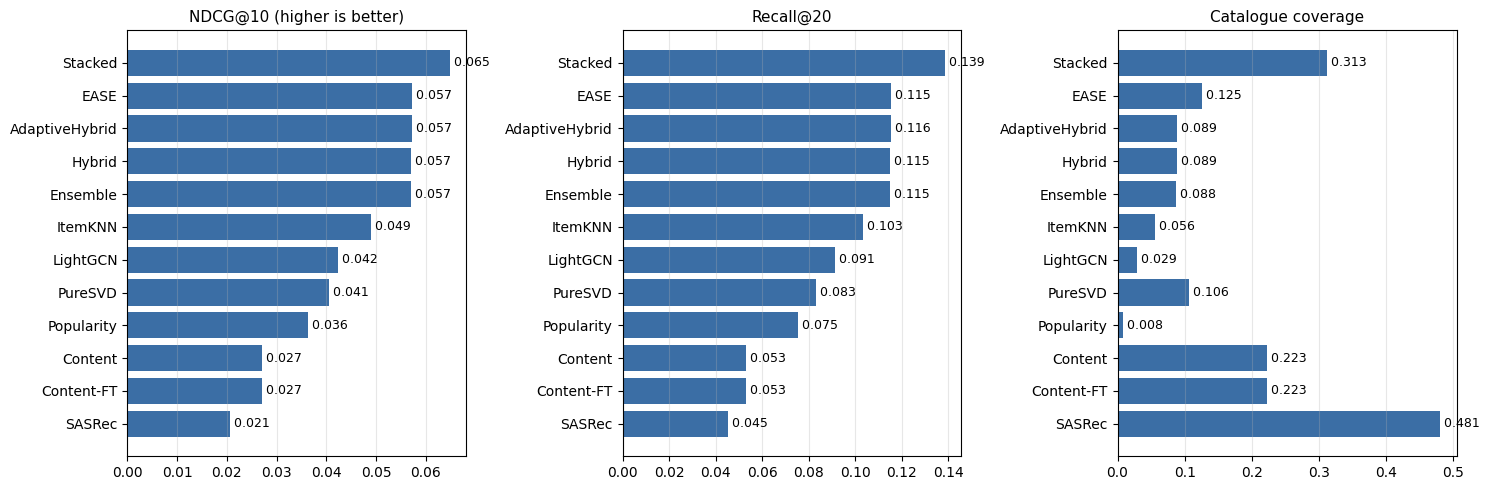

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
order = summary.index.tolist()

for ax, col, title in zip(
    axes,
    [f"NDCG@{PRIMARY_K}", "Recall@20", "Coverage"],
    [f"NDCG@{PRIMARY_K} (higher is better)", "Recall@20", "Catalogue coverage"],
):
    vals = summary[col].values
    ax.barh(order, vals, color="#3b6ea5")
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)
    ax.grid(axis="x", alpha=0.3)
    for i, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(v, i, f" {v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "model_comparison_v6.png", dpi=140, bbox_inches="tight")
plt.show()


## 17. History-bucket breakdown — where does each addition actually help?

In [35]:
def performance_by_history(model, users, buckets=ADAPTIVE_BUCKETS):
    hist = np.diff(X_train.indptr)
    out = []
    for lo, hi in buckets:
        sel = users[(hist[users] >= lo) & (hist[users] < hi)]
        if len(sel) < 50:
            continue
        m = evaluate(model, sel, X_train, X_test, ks=(PRIMARY_K,), collect_items=False)
        out.append({
            "history": f"{lo}-{hi if hi < 10**8 else '+'}",
            "users": len(sel),
            f"ndcg@{PRIMARY_K}": round(m[f"ndcg@{PRIMARY_K}"], 4),
        })
    return pd.DataFrame(out)


models_to_compare = {"EASE": ease_model, "AdaptiveHybrid": adaptive_hybrid_model}
if TRAIN_SASREC:
    models_to_compare["SASRec"] = sasrec_scorer
if TRAIN_LIGHTGCN:
    models_to_compare["LightGCN"] = lightgcn_scorer
if TRAIN_STACKER:
    models_to_compare["Stacked"] = stacked_scorer

cold_analysis = None
for name, model in models_to_compare.items():
    df_i = performance_by_history(model, eval_users).rename(
        columns={f"ndcg@{PRIMARY_K}": f"ndcg@{PRIMARY_K}_{name}"}
    )
    cold_analysis = df_i if cold_analysis is None else cold_analysis.merge(
        df_i, on=["history", "users"]
    )

cold_analysis


,history,users,ndcg@10_EASE,ndcg@10_AdaptiveHybrid,ndcg@10_SASRec,ndcg@10_LightGCN,ndcg@10_Stacked
0,5-20,2882,0.0661,0.0758,0.0000,0.0644,0.0798
1,20-50,2765,0.0621,0.0645,0.0000,0.0430,0.0650
2,50-150,2969,0.0556,0.0474,0.0491,0.0314,0.0580
3,150-+,1384,0.0334,0.0256,0.0433,0.0189,0.0488


## 18. Inference

Default scorer is `stacked_scorer` if trained, else `adaptive_hybrid_model`.
Check section 16's results table before trusting this default — pick
whichever row actually wins on your data.

In [36]:
_default_model = stacked_scorer if TRAIN_STACKER else adaptive_hybrid_model
print(f"  default inference model: {_default_model.name}")


def _titles(item_indices, extra=None):
    out = item_meta.iloc[item_indices][["movieId", "title", "genres"]].reset_index(drop=True)
    if extra is not None:
        for col, vals in extra.items():
            out[col] = vals
    return out


def recommend_for_user(user_id, k=10, model=None, exclude_seen=True):
    model = model or _default_model
    if user_id not in user_to_idx:
        raise KeyError(f"unknown userId {user_id}; use recommend_from_items() instead")

    u = user_to_idx[user_id]
    scores = np.asarray(model.score(np.array([u])), dtype=np.float32)[0]
    if exclude_seen:
        scores[X_train[u].indices] = -np.inf

    top = np.argpartition(-scores, k)[:k]
    top = top[np.argsort(-scores[top])]
    return _titles(top, {"score": scores[top]})


demo_user_idx = eval_users[0]
demo_user_id = int(idx_to_user[demo_user_idx])

history = item_meta.iloc[X_train[demo_user_idx].indices[-8:]][["title", "genres"]]
truth = item_meta.iloc[X_test[demo_user_idx].indices][["movieId", "title"]]

print(f"userId {demo_user_id} — recent history:")
display(history)
print("held-out (what they actually liked next):")
display(truth)
print(f"recommended ({_default_model.name}):")
display(recommend_for_user(demo_user_id, k=10))


  default inference model: Stacked
userId 64567 — recent history:


,title,genres
3504,Saving Silverman (Evil Woman) (2001),Comedy|Romance
3519,15 Minutes (2001),Thriller
3601,"Mummy Returns, The (2001)",Action|Adventure|Comedy|Thriller
3623,Summer Rental (1985),Comedy
3635,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...
3637,Pearl Harbor (2001),Action|Drama|Romance|War
3650,Mississippi Burning (1988),Crime|Drama|Thriller
3668,Swordfish (2001),Action|Crime|Drama


held-out (what they actually liked next):


,movieId,title
203,216,Billy Madison (1995)
1521,1799,Suicide Kings (1997)
3074,3623,Mission: Impossible II (2000)
3185,3755,"Perfect Storm, The (2000)"
3503,4148,Hannibal (2001)


recommended (Stacked):


,movieId,title,genres,score
0,3753,"Patriot, The (2000)",Action|Drama|War,1.265768
1,3969,Pay It Forward (2000),Drama,1.265108
2,3717,Gone in 60 Seconds (2000),Action|Crime,1.247419
3,3996,"Crouching Tiger, Hidden Dragon (Wo hu cang lon...",Action|Drama|Romance,1.203115
4,3555,U-571 (2000),Action|Thriller|War,1.041645
5,3481,High Fidelity (2000),Comedy|Drama|Romance,1.035662
6,3623,Mission: Impossible II (2000),Action|Adventure|Thriller,1.023177
7,3510,Frequency (2000),Drama|Thriller,0.960009
8,4034,Traffic (2000),Crime|Drama|Thriller,0.916735
9,3827,Space Cowboys (2000),Action|Adventure|Comedy|Sci-Fi,0.805512


## 19. Save

Saves the EASE+ItemKNN ensemble matrix (sparsified), the content
similarity matrix, SASRec weights, LightGCN weights, and the stacker —
everything needed to reload and serve without retraining.

In [37]:
def sparsify(B: np.ndarray, keep_per_col=500) -> sp.csr_matrix:
    n = B.shape[0]
    out = np.zeros_like(B)
    for start in range(0, n, 1024):
        end = min(start + 1024, n)
        block = B[:, start:end]
        kk = min(keep_per_col, n - 1)
        idx = np.argpartition(-block, kk - 1, axis=0)[:kk]
        c = np.arange(end - start)[None, :]
        out[idx, c + start] = block[idx, c]
    return sp.csr_matrix(out)


B_ensemble_dense = (best_beta * ease_model.B_ + (1 - best_beta) * S_dense).astype(np.float32)
B_sparse = sparsify(B_ensemble_dense)

sp.save_npz(OUT_DIR / "ensemble_B_sparse.npz", B_sparse)
sp.save_npz(OUT_DIR / "content_knn_ft.npz", S_content_ft)
np.save(OUT_DIR / "item_ids.npy", idx_to_item)
np.save(OUT_DIR / "user_ids.npy", idx_to_user)
item_meta[["movieId", "title", "genres", "item_idx"]].to_csv(OUT_DIR / "item_meta.csv", index=False)

if TRAIN_SASREC:
    core = sasrec_model.module if isinstance(sasrec_model, nn.DataParallel) else sasrec_model
    torch.save(core.state_dict(), OUT_DIR / "sasrec_state_dict.pt")

if TRAIN_LIGHTGCN:
    torch.save(lightgcn_model.state_dict(), OUT_DIR / "lightgcn_state_dict.pt")

if TRAIN_STACKER:
    import pickle
    with open(OUT_DIR / "stacker.pkl", "wb") as f:
        pickle.dump({"model": stacker, "mode": STACKER_MODE}, f)

import json
json.dump(
    {
        "weight_scheme": WEIGHT_SCHEME,
        "ease_lambda": best_lam,
        "ensemble_beta": best_beta,
        "bucket_alphas": [{"range": list(r), "alpha": a} for r, a in bucket_alphas],
        "content_finetuned": bool(FINETUNE_CONTENT_ENCODER),
        "sasrec_trained": TRAIN_SASREC,
        "sasrec_content_fusion": SASREC_CONTENT_FUSION if TRAIN_SASREC else None,
        "sasrec_hpo_run": SASREC_RUN_HPO if TRAIN_SASREC else None,
        "sasrec_config": {
            "dim": SASREC_EMBED_DIM, "n_blocks": SASREC_N_BLOCKS,
            "n_heads": SASREC_N_HEADS, "dropout": SASREC_DROPOUT,
        } if TRAIN_SASREC else None,
        "lightgcn_trained": TRAIN_LIGHTGCN,
        "lightgcn_content_fusion": LIGHTGCN_CONTENT_FUSION if TRAIN_LIGHTGCN else None,
        "lightgcn_hpo_run": LIGHTGCN_RUN_HPO if TRAIN_LIGHTGCN else None,
        "lightgcn_config": {
            "dim": LIGHTGCN_DIM, "layers": LIGHTGCN_LAYERS, "lr": LIGHTGCN_LR,
        } if TRAIN_LIGHTGCN else None,
        "stacker_trained": TRAIN_STACKER,
        "stacker_lib": STACKER_LIB if TRAIN_STACKER else None,
        "n_users": int(N_USERS),
        "n_items": int(N_ITEMS),
        "max_items": MAX_ITEMS,
        "metrics": {k: {kk: vv for kk, vv in v.items() if not kk.startswith("_")}
                    for k, v in RESULTS.items()},
    },
    open(OUT_DIR / "model_config_v6.json", "w"), indent=2,
)
print("saved:", *[p.name for p in sorted(OUT_DIR.glob('*')) if p.is_file()], sep="\n  ")


saved:
  __notebook__.ipynb
  content_knn_ft.npz
  ensemble_B_sparse.npz
  item_ids.npy
  item_meta.csv
  lightgcn_state_dict.pt
  model_comparison_v6.png
  model_config_v6.json
  results_summary_v6.csv
  sasrec_state_dict.pt
  stacker.pkl
  user_ids.npy


## 20. Notes and where to go next

**Reading the HPO tables.** `sasrec_hpo_df` / `lightgcn_hpo_df` rank
configs by a short-probe val NDCG (only `SASREC_HPO_EPOCHS` /
`LIGHTGCN_HPO_EPOCHS` epochs each) — that's enough to rank configs
relative to each other, but the absolute NDCG values there will be lower
than what the winning config reaches after its full patience-based run.
Don't compare a probe score to a `RESULTS` table entry directly.

**If `LightGCN` underperforms `Ensemble`/`EASE`.** Graph models are more
sensitive to the negative-sampling scheme than EASE's closed form. With
patience-based training this mostly self-corrects (it'll keep training
until val NDCG stalls), but if it's stopping very early, try raising
`LIGHTGCN_PATIENCE` — a couple of flat epochs isn't always true
convergence for BPR, whose loss curve is noisier than EASE's exact solve.

**If content fusion doesn't help SASRec/LightGCN.** Compare against
`SASREC_CONTENT_FUSION = False` / `LIGHTGCN_CONTENT_FUSION = False`
directly — if `content_emb_ft` fell back to weak TF-IDF vectors (because
`FINETUNE_CONTENT_ENCODER = False` or tags are sparse for your catalogue),
fusing in a weak signal may not beat pure collaborative embeddings. Unlike
v5's init-only approach, this is now easy to check post-hoc too: a learned
`content_gate` near 0 (i.e. `sigmoid(gate)` close to 0) after training
means the model itself decided to mostly ignore the content residual —
print `torch.sigmoid(core.content_gate).item()` after training to see what
it converged to.

**If `Stacked` doesn't beat the best individual model.** Check the printed
feature importances first — if `lightgcn_score` or `sasrec_score` has near-
zero importance, that model isn't adding information beyond what
`ensemble_score` already captures for your data, and dropping it from
serving saves compute without hurting results. Also try raising
`TUNING_USERS` — a `LGBMRanker` with too few groups to learn from will
default toward whichever single feature is most globally predictive.

**Genuinely bigger steps from here**, still skipped on purpose:

- **BERT4Rec** — bidirectional attention (masked-item prediction) instead
  of SASRec's causal setup; often a small, real improvement.
- **Two-tower retrieval + `faiss`** — replace brute-force top-N candidate
  generation with approximate nearest neighbours, so candidate generation
  scales past 20k items without full dense score matrices.
- **Strong generalisation protocol** — hold out entire users rather than
  the last N interactions of users seen in training. Every number in this
  notebook will drop under that protocol; that's expected and is a more
  realistic test of true cold-user performance.
- **Joint end-to-end training** — right now content fine-tuning, SASRec,
  and LightGCN are trained separately and only meet at the stacker. A
  multi-task model that shares an item embedding table across the
  sequential and graph objectives (rather than three separate embedding
  spaces glued together by a reranker) is the natural next step in
  complexity, and is a much bigger engineering lift than anything in this
  notebook.
